## あらためて、小麦の国別収量可視化（2019）

FAOSTAT countries with wheat production data: 157
Mapped countries with wheat production data: 117


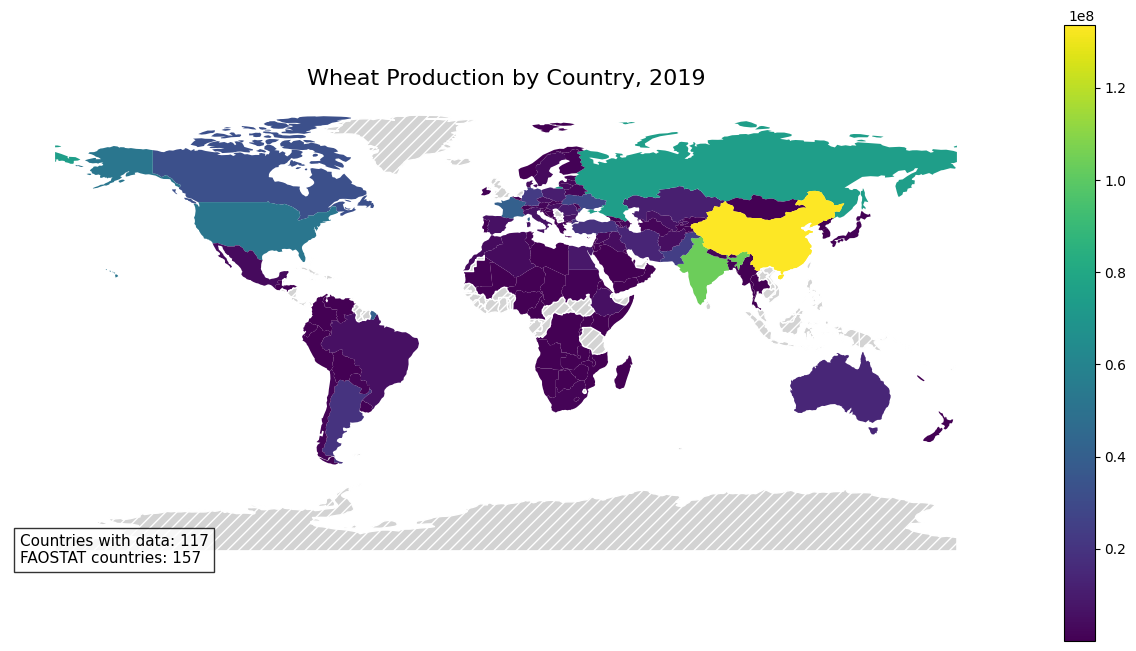

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import os

# =========================
# 設定
# =========================
input_csv = r"C:\masterresearch\Comparative_advantage\wheat_production_2019\Production_Crops_Livestock_E_All_Data_(Normalized).csv"
output_dir = r"C:\masterresearch\Comparative_advantage\wheat_production_2019\wheat_output"
os.makedirs(output_dir, exist_ok=True)

target_item_code = 15
target_year = 2019

# =========================
# 1. FAOSTAT読み込み
# =========================
df = pd.read_csv(input_csv, low_memory=False)

# =========================
# 2. Wheat × 2019 抽出
# =========================
wheat = df[
    (df["Item Code"] == target_item_code) &
    (df["Year"] == target_year)
].copy()

# =========================
# 3. 生産量だけ抽出
# =========================
wheat_prod = wheat[
    wheat["Element"].str.contains("Production", case=False, na=False)
].copy()

wheat_prod = wheat_prod[["Area", "Item", "Element", "Year", "Unit", "Value"]].copy()
wheat_prod["Value"] = pd.to_numeric(wheat_prod["Value"], errors="coerce")

out_csv = os.path.join(output_dir, f"wheat_production_{target_year}.csv")
wheat_prod.to_csv(out_csv, index=False, encoding="utf-8-sig")

# =========================
# 4. 世界地図データ読み込み
# =========================
world_url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(world_url)

# =========================
# 5. 国名対応
# =========================
name_map = {
    "United States": "United States of America",
    "Russian Federation": "Russia",
    "China, mainland": "China",
    "Iran (Islamic Republic of)": "Iran",
    "Türkiye": "Turkey",
    "Viet Nam": "Vietnam",
    "Bolivia (Plurinational State of)": "Bolivia",
    "Venezuela (Bolivarian Republic of)": "Venezuela",
    "Syrian Arab Republic": "Syria",
    "Republic of Korea": "South Korea",
    "Democratic People's Republic of Korea": "North Korea",
    "Lao People's Democratic Republic": "Laos",
    "United Republic of Tanzania": "Tanzania",
    "Côte d'Ivoire": "Ivory Coast",
    "Congo": "Republic of the Congo",
    "Republic of Moldova": "Moldova",
    "North Macedonia": "Macedonia",
}

wheat_prod["Area_for_map"] = wheat_prod["Area"].replace(name_map)

# =========================
# 6. 地図データと結合
# =========================
merged = world.merge(
    wheat_prod,
    left_on="ADMIN",
    right_on="Area_for_map",
    how="left"
)

# =========================
# 7. データ国数の確認
# =========================
n_faostat_country = wheat_prod["Area"].nunique()
n_mapped_country = merged["Value"].notna().sum()

print(f"FAOSTAT countries with wheat production data: {n_faostat_country}")
print(f"Mapped countries with wheat production data: {n_mapped_country}")

# =========================
# 8. 地図で可視化
# =========================
fig, ax = plt.subplots(figsize=(16, 8))

merged.plot(
    column="Value",
    ax=ax,
    legend=True,
    cmap="viridis",
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "white",
        "hatch": "///",
        "label": "No data"
    }
)

ax.set_title(f"Wheat Production by Country, {target_year}", fontsize=16)

ax.text(
    0.01, 0.02,
    f"Countries with data: {n_mapped_country}\nFAOSTAT countries: {n_faostat_country}",
    transform=ax.transAxes,
    fontsize=11,
    bbox=dict(facecolor="white", alpha=0.8)
)

ax.axis("off")

out_png = os.path.join(output_dir, f"wheat_production_map_{target_year}.png")
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 9. 未結合国を保存
# =========================
unmatched = wheat_prod[
    ~wheat_prod["Area_for_map"].isin(world["ADMIN"])
][["Area", "Area_for_map", "Value"]].sort_values("Area")

out_unmatched = os.path.join(output_dir, f"unmatched_countries_{target_year}.csv")
unmatched.to_csv(out_unmatched, index=False, encoding="utf-8-sig")

# =========================
# 10. 上位国を保存
# =========================
top = wheat_prod.sort_values("Value", ascending=False).head(20)

out_top = os.path.join(output_dir, f"top20_wheat_production_{target_year}.csv")
top.to_csv(out_top, index=False, encoding="utf-8-sig")

# 2024年版やったらデータなし減るのか？

FAOSTAT countries with wheat production data: 156
Mapped countries with wheat production data: 116


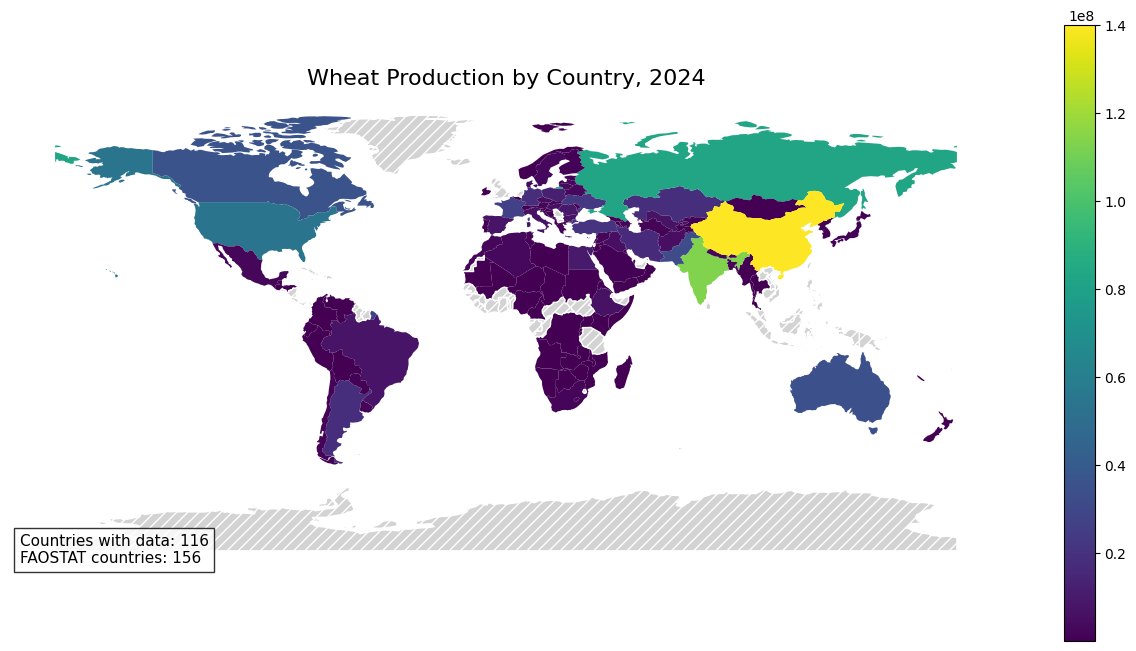

                                                         Area                                          Area_for_map         Value
3227104                                                Africa                                                Africa  2.610087e+07
3410667                                              Americas                                              Americas  1.221438e+08
3576317                                                  Asia                                                  Asia  3.720194e+08
3942651                             Australia and New Zealand                             Australia and New Zealand  3.457460e+07
3471709                                       Central America                                       Central America  2.650421e+06
3593013                                          Central Asia                                          Central Asia  2.818162e+07
638722                              China, Taiwan Province of                             

In [3]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import os

# =========================
# 設定
# =========================
input_csv = r"C:\masterresearch\Comparative_advantage\wheat_production_2019\Production_Crops_Livestock_E_All_Data_(Normalized).csv"
output_dir = r"C:\masterresearch\Comparative_advantage\wheat_production_2019\wheat_output"
os.makedirs(output_dir, exist_ok=True)
#コメは27、小麦は15
target_item_code = 15
target_year = 2024

# =========================
# 1. FAOSTAT読み込み
# =========================
df = pd.read_csv(input_csv, low_memory=False)

# =========================
# 2. Wheat × 2019 抽出
# =========================
wheat = df[
    (df["Item Code"] == target_item_code) &
    (df["Year"] == target_year)
].copy()

# =========================
# 3. 生産量だけ抽出
# =========================
wheat_prod = wheat[
    wheat["Element"].str.contains("Production", case=False, na=False)
].copy()

wheat_prod = wheat_prod[["Area", "Item", "Element", "Year", "Unit", "Value"]].copy()
wheat_prod["Value"] = pd.to_numeric(wheat_prod["Value"], errors="coerce")

out_csv = os.path.join(output_dir, f"wheat_production_{target_year}.csv")
wheat_prod.to_csv(out_csv, index=False, encoding="utf-8-sig")

# =========================
# 4. 世界地図データ読み込み
# =========================
world_url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(world_url)

# =========================
# 5. 国名対応
# =========================
name_map = {
    "United States": "United States of America",
    "Russian Federation": "Russia",
    "China, mainland": "China",
    "Iran (Islamic Republic of)": "Iran",
    "Türkiye": "Turkey",
    "Viet Nam": "Vietnam",
    "Bolivia (Plurinational State of)": "Bolivia",
    "Venezuela (Bolivarian Republic of)": "Venezuela",
    "Syrian Arab Republic": "Syria",
    "Republic of Korea": "South Korea",
    "Democratic People's Republic of Korea": "North Korea",
    "Lao People's Democratic Republic": "Laos",
    "United Republic of Tanzania": "Tanzania",
    "Côte d'Ivoire": "Ivory Coast",
    "Congo": "Republic of the Congo",
    "Republic of Moldova": "Moldova",
    "North Macedonia": "Macedonia",
}

wheat_prod["Area_for_map"] = wheat_prod["Area"].replace(name_map)

# =========================
# 6. 地図データと結合
# =========================
merged = world.merge(
    wheat_prod,
    left_on="ADMIN",
    right_on="Area_for_map",
    how="left"
)

# =========================
# 7. データ国数の確認
# =========================
n_faostat_country = wheat_prod["Area"].nunique()
n_mapped_country = merged["Value"].notna().sum()

print(f"FAOSTAT countries with wheat production data: {n_faostat_country}")
print(f"Mapped countries with wheat production data: {n_mapped_country}")

# =========================
# 8. 地図で可視化
# =========================
fig, ax = plt.subplots(figsize=(16, 8))

merged.plot(
    column="Value",
    ax=ax,
    legend=True,
    cmap="viridis",
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "white",
        "hatch": "///",
        "label": "No data"
    }
)

ax.set_title(f"Wheat Production by Country, {target_year}", fontsize=16)

ax.text(
    0.01, 0.02,
    f"Countries with data: {n_mapped_country}\nFAOSTAT countries: {n_faostat_country}",
    transform=ax.transAxes,
    fontsize=11,
    bbox=dict(facecolor="white", alpha=0.8)
)

ax.axis("off")

out_png = os.path.join(output_dir, f"wheat_production_map_{target_year}.png")
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 9. 未結合国を保存
# =========================
unmatched = wheat_prod[
    ~wheat_prod["Area_for_map"].isin(world["ADMIN"])
][["Area", "Area_for_map", "Value"]].sort_values("Area")

out_unmatched = os.path.join(output_dir, f"unmatched_countries_{target_year}.csv")
unmatched.to_csv(out_unmatched, index=False, encoding="utf-8-sig")

# =========================
# 10. 上位国を保存
# =========================
top = wheat_prod.sort_values("Value", ascending=False).head(20)

out_top = os.path.join(output_dir, f"top20_wheat_production_{target_year}.csv")
top.to_csv(out_top, index=False, encoding="utf-8-sig")
print(unmatched.to_string())

## Agro-climatic potentialを描画、国別集計

===== Raster Information =====
CRS         : EPSG:4326
Bounds      : BoundingBox(left=-180.0, bottom=-90.0, right=180.0, top=90.0)
Resolution  : (0.08333333333333333, 0.08333333333333333)
Width       : 4320
Height      : 2160
NoData      : -9.0

===== Data Statistics =====
Minimum : 0.00
Maximum : 14010.87
Mean    : 2080.22


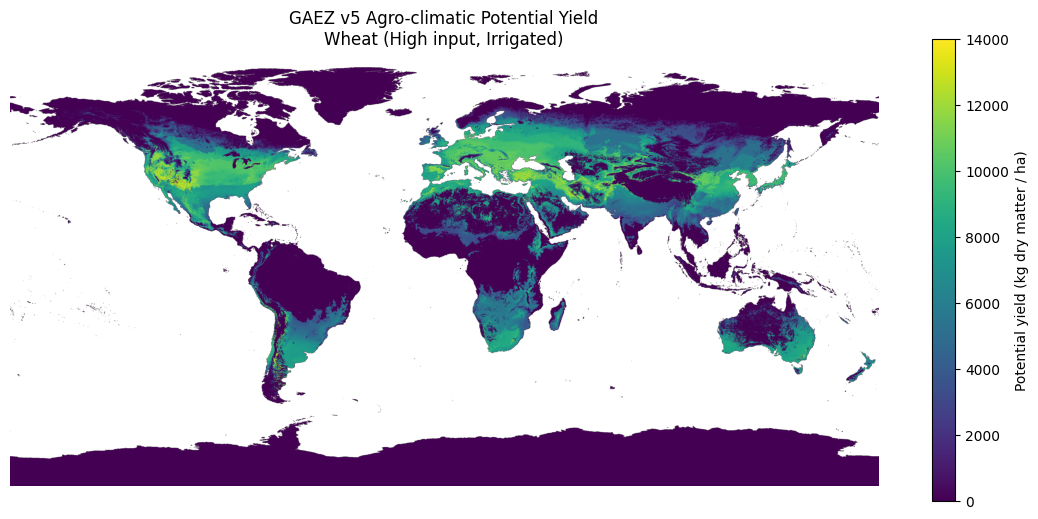

In [4]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# ファイルパス
# ===============================
tif_path = r"C:\masterresearch\Comparative_advantage\GAEZ\wheat\GAEZ-V5.RES02-YLD.HP0120.AGERA5.HIST.WHEA.HILM.tif"

# ===============================
# 読み込み
# ===============================
with rasterio.open(tif_path) as src:
    data = src.read(1)

    print("===== Raster Information =====")
    print(f"CRS         : {src.crs}")
    print(f"Bounds      : {src.bounds}")
    print(f"Resolution  : {src.res}")
    print(f"Width       : {src.width}")
    print(f"Height      : {src.height}")
    print(f"NoData      : {src.nodata}")

# ===============================
# NoDataをNaNへ
# ===============================
if src.nodata is not None:
    data = np.where(data == src.nodata, np.nan, data)

print("\n===== Data Statistics =====")
print(f"Minimum : {np.nanmin(data):.2f}")
print(f"Maximum : {np.nanmax(data):.2f}")
print(f"Mean    : {np.nanmean(data):.2f}")

# ===============================
# 描画
# ===============================
plt.figure(figsize=(14,6))
plt.imshow(data, cmap="viridis")
plt.colorbar(label="Potential yield (kg dry matter / ha)")
plt.title("GAEZ v5 Agro-climatic Potential Yield\nWheat (High input, Irrigated)")
plt.axis("off")
'''
plt.xlim(3000,4000)
plt.ylim(1500,500)
'''
plt.show()


# numpyにしておく

In [5]:
import rasterio
import numpy as np

tif_path = r"C:\masterresearch\Comparative_advantage\GAEZ\wheat\GAEZ-V5.RES02-YLD.HP0120.AGERA5.HIST.WHEA.HILM.tif"

with rasterio.open(tif_path) as src:
    data = src.read(1)

    # NoDataをNaNへ
    if src.nodata is not None:
        data = np.where(data == src.nodata, np.nan, data)

    transform = src.transform
    crs = src.crs

# 保存
np.save(r"C:\masterresearch\Comparative_advantage\GAEZ\wheat\CPY_wheat.npy", data)

# 必要なら空間情報も保存
meta = {
    "transform": transform,
    "crs": crs,
}
np.save(r"C:\masterresearch\Comparative_advantage\GAEZ\wheat\CPY_meta.npy",
        meta, allow_pickle=True)

In [6]:
import numpy as np

wheat_CPY = np.load(
    r"C:\masterresearch\Comparative_advantage\GAEZ\wheat\CPY_wheat.npy"
)

print(wheat_CPY.shape)

(2160, 4320)


In [7]:
import rasterio
import numpy as np

tif_path = r"C:\masterresearch\Comparative_advantage\GAEZ\wheat\GAEZ-V5.RES05-YLX.HP0120.AGERA5.HIST.WHE.HILM.tif"

with rasterio.open(tif_path) as src:
    data = src.read(1)

    # NoDataをNaNへ
    if src.nodata is not None:
        data = np.where(data == src.nodata, np.nan, data)

    transform = src.transform
    crs = src.crs

# 保存
np.save(r"C:\masterresearch\Comparative_advantage\GAEZ\wheat\AttainableYield_wheat.npy", data)

# 必要なら空間情報も保存
meta = {
    "transform": transform,
    "crs": crs,
}
np.save(r"C:\masterresearch\Comparative_advantage\GAEZ\wheat\Attainable_wheat_meta.npy",
        meta, allow_pickle=True)

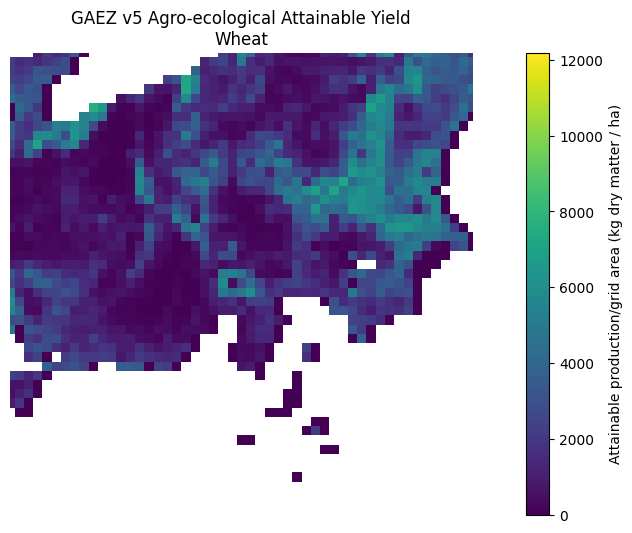

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 読み込み
wheat_ATY = np.load(
    r"C:\masterresearch\Comparative_advantage\GAEZ\wheat\AttainableYield_wheat.npy"
)

# 描画
plt.figure(figsize=(14, 6))

im = plt.imshow(
    wheat_ATY,
    cmap="viridis",
    origin="upper"
)

plt.colorbar(im, label="Attainable production/grid area (kg dry matter / ha)")
plt.title("GAEZ v5 Agro-ecological Attainable Yield\nWheat")
plt.axis("off")

plt.xlim(3800,3850)
plt.ylim(680,630)

plt.show()

## attainable yield/climatic potential yieldしてみる

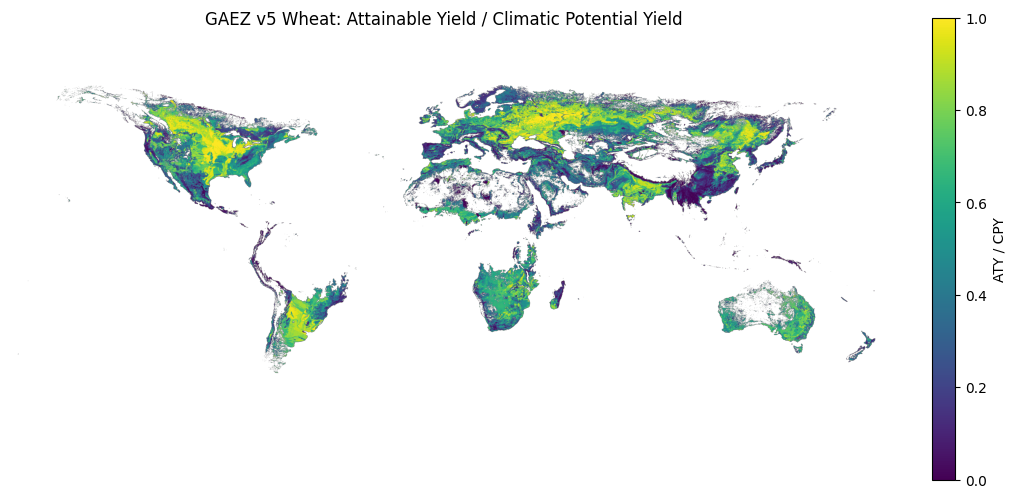

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 0やNaNを考慮して比率を計算
proportion = np.divide(
    wheat_ATY,
    wheat_CPY,
    out=np.full_like(wheat_ATY, np.nan, dtype=float),
    where=(wheat_CPY > 0)
)

plt.figure(figsize=(14,6))

im = plt.imshow(
    proportion,
    cmap="viridis",
    origin="upper",
    vmin=0,
    vmax=1
)

plt.colorbar(im, label="ATY / CPY")
plt.title("GAEZ v5 Wheat: Attainable Yield / Climatic Potential Yield")
plt.axis("off")
'''
plt.xlim(3000,4000)
plt.ylim(1500,500)
'''
plt.show()

## いったん、attainable yield×グリッド面積が国別生産量と相関があるか、見てみる

## まずはグリッド面積をとってくる

In [10]:
import numpy as np

# grid size
nlat = 2160
nlon = 4320

# Earth radius [m]
R = 6371000

# resolution [degree]
dlat = 180 / nlat
dlon = 360 / nlon

# latitude edges: 90 to -90
lat_edges = np.linspace(90, -90, nlat + 1)

# radian
lat1 = np.deg2rad(lat_edges[:-1])
lat2 = np.deg2rad(lat_edges[1:])
dlon_rad = np.deg2rad(dlon)

# area for each latitude band, per grid cell [m2]
# 面積 = R^2 * Δlon * |sin(lat_north) - sin(lat_south)|
area_1d = R**2 * dlon_rad * np.abs(np.sin(lat1) - np.sin(lat2))

# 2160 x 4320 に展開
grid_area_m2 = np.repeat(area_1d[:, None], nlon, axis=1)

# hectares
grid_area_ha = grid_area_m2 / 10000

print(grid_area_ha.shape)
print(grid_area_ha.min(), grid_area_ha.max())

# 保存
np.save(r"C:\masterresearch\Comparative_advantage\GAEZ\grid_area_2160x4320_ha.npy", grid_area_ha)

(2160, 4320)
6.24415251920592 8586.32455017297


## 国別集計

ATY shape: (2160, 4320)
Area shape: (2160, 4320)
Global attainable production [tonnes]: 22508483646.468246
country_raster shape: (2160, 4320)
country pixels: 2227348
Saved CSV: C:\masterresearch\Comparative_advantage\GAEZ\wheat\country_attainable_production\wheat_attainable_production_by_country.csv


,country_id,country,iso_a3,attainable_production_tonnes,valid_grid_area_ha,mean_attainable_yield_kg_ha
0,5,United States of America,USA,4.322323e+09,7.640252e+08,5657.304353
1,19,Russia,RUS,2.538617e+09,6.561908e+08,3868.717876
2,140,China,CHN,1.734623e+09,5.824403e+08,2978.199193
3,138,Australia,AUS,1.481249e+09,3.511964e+08,4217.721541
4,10,Argentina,ARG,1.052793e+09,2.008514e+08,5241.649376
5,4,Canada,CAN,9.739412e+08,3.168216e+08,3074.099512
6,6,Kazakhstan,KAZ,7.938364e+08,2.151611e+08,3689.498324
7,99,India,IND,6.649278e+08,2.301068e+08,2889.649013
8,113,Ukraine,UKR,4.691506e+08,5.684273e+07,8253.484866
9,26,South Africa,ZAF,4.379556e+08,1.171470e+08,3738.512002


c:\Users\tsuda\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


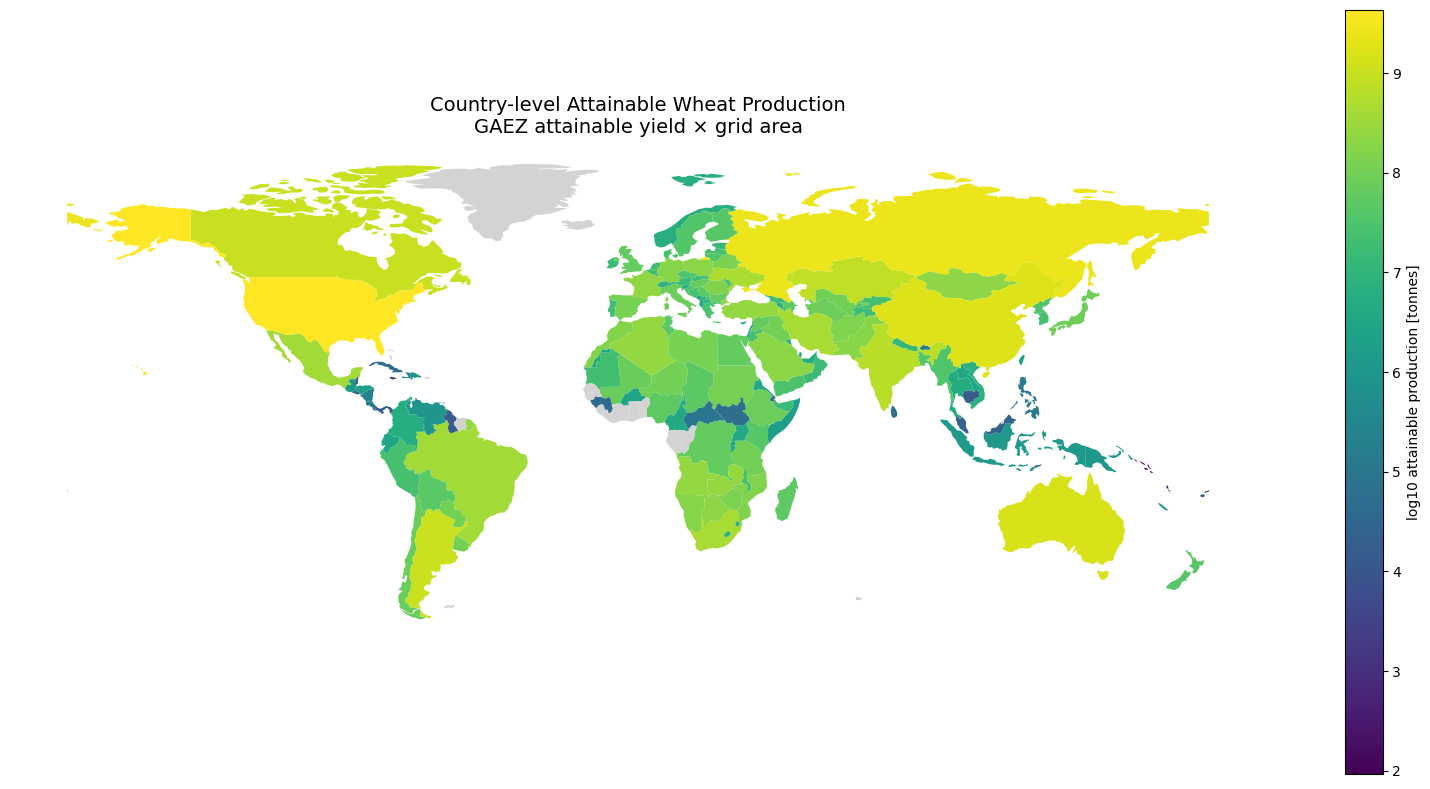

Saved map: C:\masterresearch\Comparative_advantage\GAEZ\wheat\country_attainable_production\wheat_attainable_production_by_country_map.png


In [11]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from rasterio.transform import from_bounds
from rasterio.features import rasterize

# ============================================================
# 設定
# ============================================================
base_dir = r"C:\masterresearch\Comparative_advantage\GAEZ"
crop = "wheat"
crop_dir = os.path.join(base_dir, crop)

aty_path = os.path.join(crop_dir, "AttainableYield_wheat.npy")
area_path = os.path.join(base_dir, "grid_area_2160x4320_ha.npy")

output_dir = os.path.join(crop_dir, "country_attainable_production")
os.makedirs(output_dir, exist_ok=True)

out_csv = os.path.join(output_dir, "wheat_attainable_production_by_country.csv")
out_map = os.path.join(output_dir, "wheat_attainable_production_by_country_map.png")

# ============================================================
# 1. データ読み込み
# ============================================================
wheat_ATY = np.load(aty_path)          # kg/ha
grid_area_ha = np.load(area_path)      # ha/grid

print("ATY shape:", wheat_ATY.shape)
print("Area shape:", grid_area_ha.shape)

assert wheat_ATY.shape == grid_area_ha.shape, "ATYと面積のshapeが違います"

height, width = wheat_ATY.shape

# ============================================================
# 2. attainable yield × grid area
#    kg/ha × ha = kg
# ============================================================
valid = (
    np.isfinite(wheat_ATY)
    & np.isfinite(grid_area_ha)
    & (wheat_ATY > 0)
    & (grid_area_ha > 0)
)

attainable_prod_kg = np.where(
    valid,
    wheat_ATY * grid_area_ha,
    0.0
)

attainable_prod_tonnes = attainable_prod_kg / 1000.0

print(
    "Global attainable production [tonnes]:",
    np.nansum(attainable_prod_tonnes)
)

# ============================================================
# 3. 国ポリゴン読み込み
# ============================================================
world_url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(world_url).to_crs("EPSG:4326")

world = world[world["ADMIN"] != "Antarctica"].copy()
world = world.reset_index(drop=True)

world["country_id"] = np.arange(1, len(world) + 1)

# ============================================================
# 4. 国ポリゴンを GAEZ グリッドに rasterize
# ============================================================
transform = from_bounds(
    -180, -90, 180, 90,
    width, height
)

shapes = [
    (geom, cid)
    for geom, cid in zip(world.geometry, world["country_id"])
    if geom is not None
]

country_raster = rasterize(
    shapes=shapes,
    out_shape=(height, width),
    transform=transform,
    fill=0,
    dtype="int32"
)

print("country_raster shape:", country_raster.shape)
print("country pixels:", np.sum(country_raster > 0))

# ============================================================
# 5. 国別集計
# ============================================================
rows = []

for _, row in world.iterrows():
    cid = row["country_id"]
    mask_country = country_raster == cid
    mask_valid_country = mask_country & valid

    prod_tonnes = attainable_prod_tonnes[mask_valid_country].sum()
    area_ha = grid_area_ha[mask_valid_country].sum()

    mean_yield = (
        prod_tonnes * 1000 / area_ha
        if area_ha > 0
        else np.nan
    )

    rows.append({
        "country_id": cid,
        "country": row["ADMIN"],
        "iso_a3": row["ISO_A3"],
        "attainable_production_tonnes": prod_tonnes,
        "valid_grid_area_ha": area_ha,
        "mean_attainable_yield_kg_ha": mean_yield
    })

country_aty = pd.DataFrame(rows)

country_aty = country_aty.sort_values(
    "attainable_production_tonnes",
    ascending=False
).reset_index(drop=True)

country_aty.to_csv(out_csv, index=False, encoding="utf-8-sig")

print("Saved CSV:", out_csv)
display(country_aty.head(30))

# ============================================================
# 6. 地図化用に結合
#    country_idだけでmergeする
# ============================================================
world_map = world.merge(
    country_aty,
    on="country_id",
    how="left",
    suffixes=("", "_sum")
)

world_map["log10_attainable_prod"] = np.where(
    world_map["attainable_production_tonnes"] > 0,
    np.log10(world_map["attainable_production_tonnes"]),
    np.nan
)

# ============================================================
# 7. 地図描画
# ============================================================
fig, ax = plt.subplots(figsize=(16, 8))

world_map.plot(
    column="log10_attainable_prod",
    ax=ax,
    legend=True,
    cmap="viridis",
    missing_kwds={
        "color": "lightgrey",
        "label": "No data / zero"
    },
    legend_kwds={
        "label": "log10 attainable production [tonnes]"
    }
)

ax.set_title(
    "Country-level Attainable Wheat Production\n"
    "GAEZ attainable yield × grid area",
    fontsize=14
)

ax.axis("off")
plt.tight_layout()
plt.savefig(out_map, dpi=300, bbox_inches="tight")
plt.show()

print("Saved map:", out_map)

attainable columns:
['country_id', 'country', 'iso_a3', 'attainable_production_tonnes', 'valid_grid_area_ha', 'mean_attainable_yield_kg_ha']
FAOSTAT wheat actual production:


,Area,Item,Element,Year,Unit,actual_production_tonnes
12028,Afghanistan,Wheat,Production,2024,t,5200000.0
30501,Albania,Wheat,Production,2024,t,180812.2
51705,Algeria,Wheat,Production,2024,t,3000000.0
65688,Angola,Wheat,Production,2024,t,37301.0
100854,Argentina,Wheat,Production,2024,t,18510280.0


Unit check:


Unit
t    156
Name: count, dtype: int64

Matched countries: 118


,country,iso_a3,attainable_production_tonnes,actual_production_tonnes,log_attainable,log_actual
2,China,CHN,1.734623e+09,2.802050e+08,9.239205,8.447476
7,India,IND,6.649278e+08,1.132924e+08,8.822775,8.054201
1,Russia,RUS,2.538617e+09,8.258800e+07,9.404597,7.916917
0,United States of America,USA,4.322323e+09,5.365002e+07,9.635717,7.729570
5,Canada,CAN,9.739412e+08,3.593884e+07,8.988533,7.555564
3,Australia,AUS,1.481249e+09,3.411000e+07,9.170628,7.532882
22,Pakistan,PAK,1.921827e+08,3.181444e+07,8.283714,7.502624
17,France,-99,2.333154e+08,2.660694e+07,8.367943,7.424995
8,Ukraine,UKR,4.691506e+08,2.244111e+07,8.671312,7.351044
15,Turkey,TUR,2.492454e+08,2.080000e+07,8.396627,7.318063


Saved: C:\masterresearch\Comparative_advantage\GAEZ\wheat\country_attainable_production\wheat_attainable_vs_actual_2024.csv
========== Correlation ==========
Pearson raw    : r = 0.567, p = 2.28e-11
Spearman raw   : rho = 0.687, p = 9.38e-18
Pearson log10  : r = 0.705, p = 4.83e-19
Spearman log10 : rho = 0.687, p = 9.38e-18


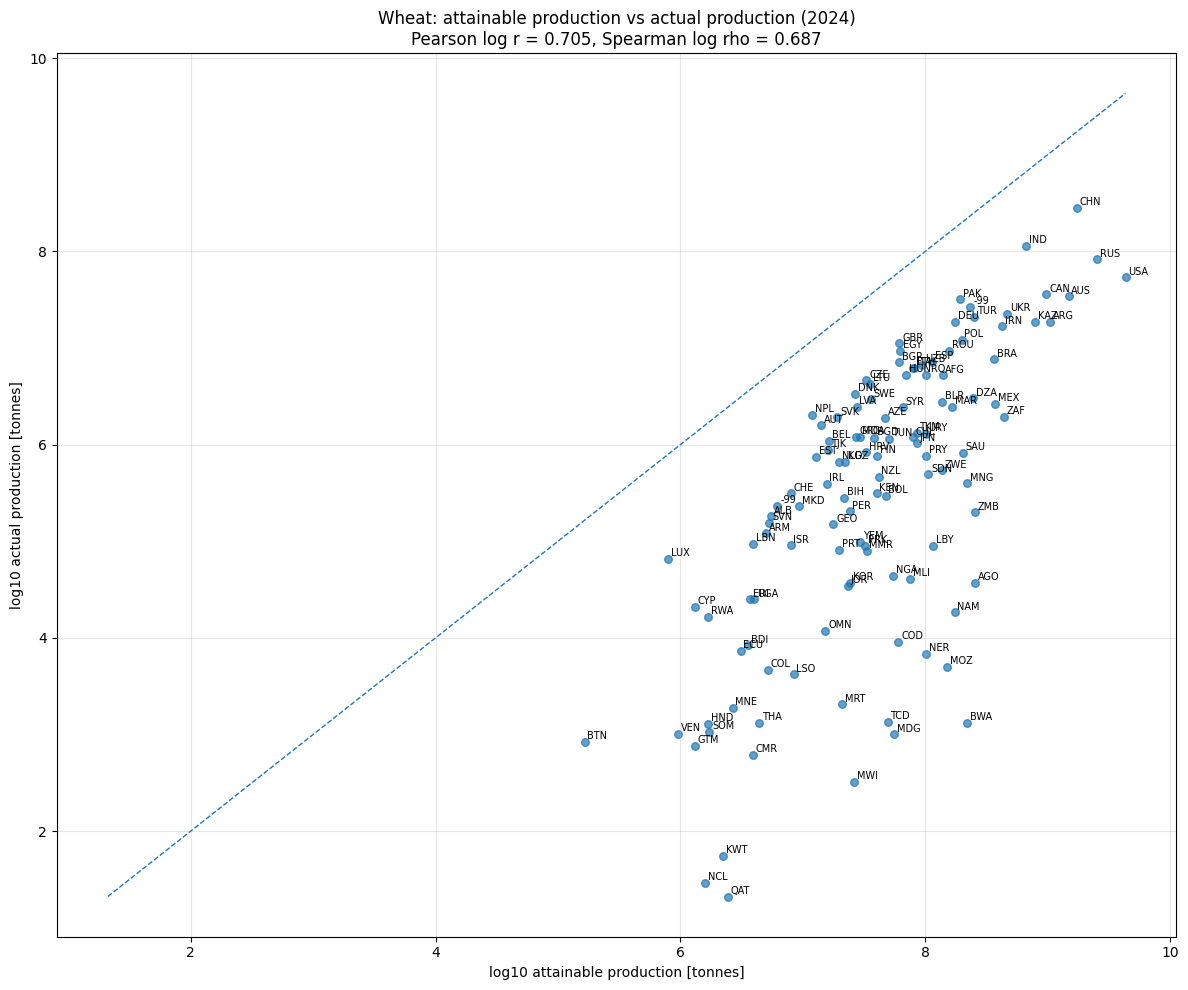

Unmatched actual-production countries:


,country,actual_production_tonnes
151,World,7.984817e+08
8,Asia,3.720194e+08
46,Europe,2.436430e+08
127,Southern Asia,1.702655e+08
39,Eastern Europe,1.493398e+08
38,Eastern Asia,1.416587e+08
4,Americas,1.221438e+08
47,European Union (27),1.194105e+08
102,Northern America,8.958886e+07
93,Net Food Importing Developing Countries (NFIDCs),6.154003e+07


In [12]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# ============================================================
# 設定
# ============================================================
base_dir = r"C:\masterresearch\Comparative_advantage"

attainable_csv = (
    r"C:\masterresearch\Comparative_advantage\GAEZ\wheat"
    r"\country_attainable_production\wheat_attainable_production_by_country.csv"
)

# ノート内で使っていたFAOSTATの元データ
faostat_csv = (
    r"C:\masterresearch\Comparative_advantage\wheat_production_2019"
    r"\Production_Crops_Livestock_E_All_Data_(Normalized).csv"
)

output_dir = (
    r"C:\masterresearch\Comparative_advantage\GAEZ\wheat"
    r"\country_attainable_production"
)
os.makedirs(output_dir, exist_ok=True)

target_item_code = 15   # wheat
target_year = 2024      # 2019にしたければここを変更

out_merged_csv = os.path.join(
    output_dir,
    f"wheat_attainable_vs_actual_{target_year}.csv"
)

out_scatter = os.path.join(
    output_dir,
    f"wheat_attainable_vs_actual_{target_year}_scatter.png"
)

# ============================================================
# 1. attainable production 読み込み
# ============================================================
attainable = pd.read_csv(attainable_csv)

print("attainable columns:")
print(attainable.columns.tolist())

# ============================================================
# 2. FAOSTATから小麦の実生産量を抽出
# ============================================================
df = pd.read_csv(faostat_csv, low_memory=False)

wheat_actual = df[
    (df["Item Code"] == target_item_code)
    & (df["Year"] == target_year)
    & (df["Element"].str.contains("Production", case=False, na=False))
].copy()

wheat_actual["actual_production_tonnes"] = pd.to_numeric(
    wheat_actual["Value"],
    errors="coerce"
)

wheat_actual = wheat_actual[
    ["Area", "Item", "Element", "Year", "Unit", "actual_production_tonnes"]
].copy()

print("FAOSTAT wheat actual production:")
display(wheat_actual.head())

print("Unit check:")
display(wheat_actual["Unit"].value_counts())

# ============================================================
# 3. FAOSTAT国名 → Natural Earth国名に寄せる
# ============================================================
name_map = {
    "United States": "United States of America",
    "United States of America": "United States of America",
    "Russian Federation": "Russia",
    "China, mainland": "China",
    "Iran (Islamic Republic of)": "Iran",
    "Türkiye": "Turkey",
    "Viet Nam": "Vietnam",
    "Bolivia (Plurinational State of)": "Bolivia",
    "Venezuela (Bolivarian Republic of)": "Venezuela",
    "Syrian Arab Republic": "Syria",
    "Republic of Korea": "South Korea",
    "Democratic People's Republic of Korea": "North Korea",
    "Lao People's Democratic Republic": "Laos",
    "United Republic of Tanzania": "Tanzania",
    "Czechia": "Czechia",
    "Republic of Moldova": "Moldova",
    "Netherlands (Kingdom of the)": "Netherlands",
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
    "Serbia": "Serbia",
    "Sudan (former)": "Sudan",
}

wheat_actual["country"] = wheat_actual["Area"].replace(name_map)

# ============================================================
# 4. 実生産量を国別に集計
# ============================================================
actual_country = wheat_actual.groupby("country", as_index=False).agg({
    "actual_production_tonnes": "sum"
})

# ============================================================
# 5. attainable と actual を country 名で結合
# ============================================================
df_corr = attainable.merge(
    actual_country,
    on="country",
    how="inner"
)

df_corr = df_corr[
    np.isfinite(df_corr["attainable_production_tonnes"])
    & np.isfinite(df_corr["actual_production_tonnes"])
    & (df_corr["attainable_production_tonnes"] > 0)
    & (df_corr["actual_production_tonnes"] > 0)
].copy()

df_corr["log_attainable"] = np.log10(df_corr["attainable_production_tonnes"])
df_corr["log_actual"] = np.log10(df_corr["actual_production_tonnes"])

print("Matched countries:", len(df_corr))

display(
    df_corr[[
        "country",
        "iso_a3",
        "attainable_production_tonnes",
        "actual_production_tonnes",
        "log_attainable",
        "log_actual"
    ]].sort_values("actual_production_tonnes", ascending=False).head(30)
)

df_corr.to_csv(out_merged_csv, index=False, encoding="utf-8-sig")
print("Saved:", out_merged_csv)

# ============================================================
# 6. 相関係数
# ============================================================
pearson_raw, pearson_raw_p = pearsonr(
    df_corr["attainable_production_tonnes"],
    df_corr["actual_production_tonnes"]
)

spearman_raw, spearman_raw_p = spearmanr(
    df_corr["attainable_production_tonnes"],
    df_corr["actual_production_tonnes"]
)

pearson_log, pearson_log_p = pearsonr(
    df_corr["log_attainable"],
    df_corr["log_actual"]
)

spearman_log, spearman_log_p = spearmanr(
    df_corr["log_attainable"],
    df_corr["log_actual"]
)

print("========== Correlation ==========")
print(f"Pearson raw    : r = {pearson_raw:.3f}, p = {pearson_raw_p:.3g}")
print(f"Spearman raw   : rho = {spearman_raw:.3f}, p = {spearman_raw_p:.3g}")
print(f"Pearson log10  : r = {pearson_log:.3f}, p = {pearson_log_p:.3g}")
print(f"Spearman log10 : rho = {spearman_log:.3f}, p = {spearman_log_p:.3g}")

# ============================================================
# 7. 散布図
# ============================================================
fig, ax = plt.subplots(figsize=(12, 10))

ax.scatter(
    df_corr["log_attainable"],
    df_corr["log_actual"],
    s=30,
    alpha=0.7
)

# 45度線
min_val = min(df_corr["log_attainable"].min(), df_corr["log_actual"].min())
max_val = max(df_corr["log_attainable"].max(), df_corr["log_actual"].max())

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    "--",
    linewidth=1
)

# ============================================================
# 全ての点にISO3ラベルを付ける
# ============================================================
for _, row in df_corr.iterrows():
    ax.annotate(
        row["iso_a3"],
        (row["log_attainable"], row["log_actual"]),
        xytext=(2, 2),          # 点から少しずらす
        textcoords="offset points",
        fontsize=7
    )

ax.set_xlabel("log10 attainable production [tonnes]")
ax.set_ylabel("log10 actual production [tonnes]")
ax.set_title(
    f"Wheat: attainable production vs actual production ({target_year})\n"
    f"Pearson log r = {pearson_log:.3f}, Spearman log rho = {spearman_log:.3f}"
)

ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(out_scatter, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 8. マッチしなかった国の確認
# ============================================================
matched_countries = set(df_corr["country"])

unmatched_actual = actual_country[
    ~actual_country["country"].isin(matched_countries)
].sort_values("actual_production_tonnes", ascending=False)

print("Unmatched actual-production countries:")
display(unmatched_actual.head(30))

Region counts:


region
Europe           36
Asia             34
Africa           30
South America    10
North America     5
Oceania           3
Name: count, dtype: int64

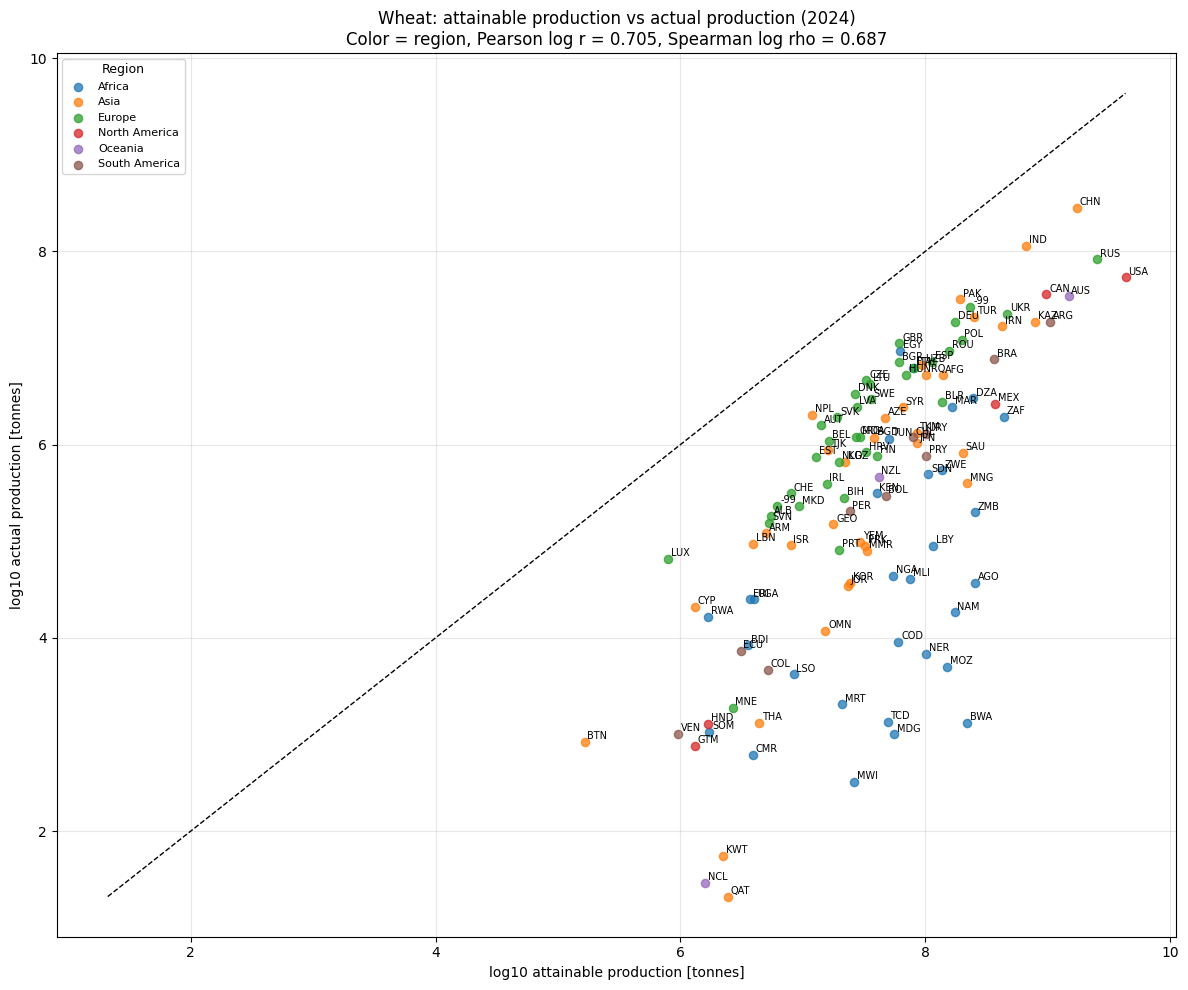

Saved: C:\masterresearch\Comparative_advantage\GAEZ\wheat\country_attainable_production\wheat_attainable_vs_actual_2024_scatter_by_region.png


In [13]:
# ============================================================
# 7. 散布図
#    色 = 地域 / 大陸
# ============================================================

# Natural Earthの地域情報を付ける
region_info = world[["ADMIN", "CONTINENT", "SUBREGION"]].copy()

df_plot = df_corr.merge(
    region_info,
    left_on="country",
    right_on="ADMIN",
    how="left"
)

df_plot["region"] = df_plot["CONTINENT"].fillna("Unknown")

print("Region counts:")
display(df_plot["region"].value_counts())

fig, ax = plt.subplots(figsize=(12, 10))

regions = sorted(df_plot["region"].dropna().unique())

for region in regions:
    sub = df_plot[df_plot["region"] == region]

    ax.scatter(
        sub["log_attainable"],
        sub["log_actual"],
        s=35,
        alpha=0.75,
        label=region
    )

# 45度線
min_val = min(df_plot["log_attainable"].min(), df_plot["log_actual"].min())
max_val = max(df_plot["log_attainable"].max(), df_plot["log_actual"].max())

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    "--",
    linewidth=1,
    color="black"
)

# 全ての点にISO3ラベル
for _, row in df_plot.iterrows():
    ax.annotate(
        row["iso_a3"],
        (row["log_attainable"], row["log_actual"]),
        xytext=(2, 2),
        textcoords="offset points",
        fontsize=7
    )

ax.set_xlabel("log10 attainable production [tonnes]")
ax.set_ylabel("log10 actual production [tonnes]")

ax.set_title(
    f"Wheat: attainable production vs actual production ({target_year})\n"
    f"Color = region, Pearson log r = {pearson_log:.3f}, Spearman log rho = {spearman_log:.3f}"
)

ax.grid(alpha=0.3)

ax.legend(
    title="Region",
    loc="best",
    fontsize=8,
    title_fontsize=9
)

plt.tight_layout()

out_scatter_region = os.path.join(
    output_dir,
    f"wheat_attainable_vs_actual_{target_year}_scatter_by_region.png"
)

plt.savefig(out_scatter_region, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_scatter_region)

            country  production_ratio
48   United Kingdom          0.181179
89            Nepal          0.172188
7             India          0.170383
22         Pakistan          0.165543
2             China          0.161537
47            Egypt          0.150724
64          Czechia          0.139986
71          Denmark          0.124791
62        Lithuania          0.119969
49         Bulgaria          0.116236
17           France          0.114039
87          Austria          0.111222
23          Germany          0.105383
81         Slovakia          0.099720
69           Latvia          0.089778
117      Luxembourg          0.083656
15           Turkey          0.083452
61           Sweden          0.081343
42         Ethiopia          0.077778
41            Italy          0.077087


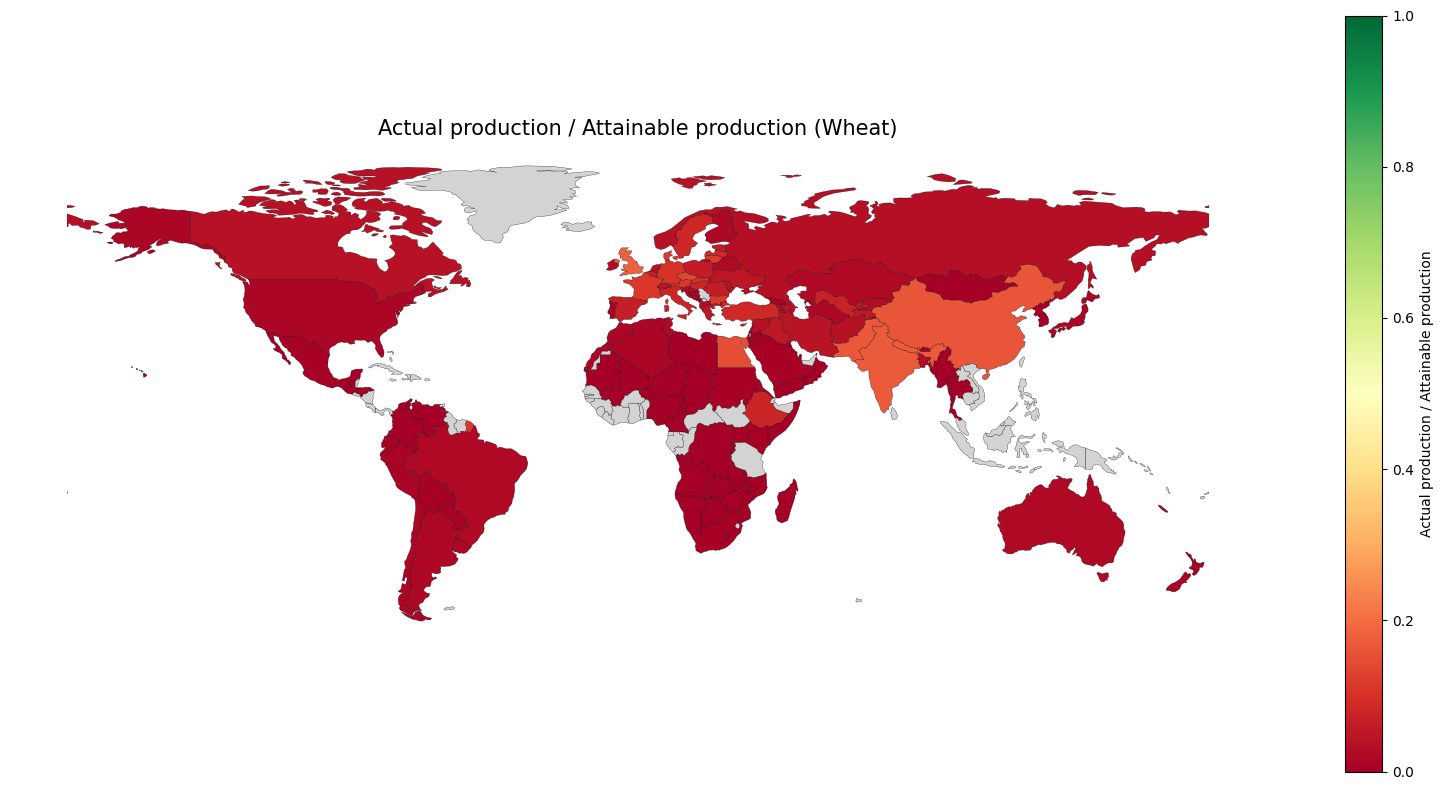

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 実生産量 / attainable production
# ============================================================
df_ratio = df_corr.copy()

df_ratio["production_ratio"] = (
    df_ratio["actual_production_tonnes"]
    / df_ratio["attainable_production_tonnes"]
)

# 念のため異常値を除く（必要に応じて変更）
df_ratio.loc[df_ratio["production_ratio"] < 0, "production_ratio"] = np.nan
df_ratio.loc[df_ratio["production_ratio"] > 2, "production_ratio"] = np.nan

print(df_ratio[[
    "country",
    "production_ratio"
]].sort_values("production_ratio", ascending=False).head(20))

# ============================================================
# 地図と結合
# ============================================================
world_ratio = world.merge(
    df_ratio[["country", "production_ratio"]],
    left_on="ADMIN",
    right_on="country",
    how="left"
)

# ============================================================
# 地図描画
# ============================================================
fig, ax = plt.subplots(figsize=(16, 8))

world_ratio.plot(
    column="production_ratio",
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    legend=True,
    ax=ax,
    edgecolor="black",
    linewidth=0.2,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    },
    legend_kwds={
        "label": "Actual production / Attainable production"
    }
)

ax.set_title(
    "Actual production / Attainable production (Wheat)",
    fontsize=15
)

ax.axis("off")

plt.tight_layout()

plt.savefig(
    os.path.join(output_dir,
    "wheat_actual_div_attainable_map.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 回帰してみる。

Number of countries: 118


,country,iso_a3,region,actual_production_tonnes,attainable_production_tonnes,actual_div_attainable,log_actual_div_attainable
48,United Kingdom,GBR,Europe,1.114600e+07,6.151926e+07,0.181179,-0.741892
89,Nepal,NPL,Asia,2.035559e+06,1.182173e+07,0.172188,-0.763997
7,India,IND,Asia,1.132924e+08,6.649278e+08,0.170383,-0.768574
22,Pakistan,PAK,Asia,3.181444e+07,1.921827e+08,0.165543,-0.781090
2,China,CHN,Asia,2.802050e+08,1.734623e+09,0.161537,-0.791729
47,Egypt,EGY,Africa,9.400000e+06,6.236559e+07,0.150724,-0.821817
64,Czechia,CZE,Europe,4.625370e+06,3.304159e+07,0.139986,-0.853914
71,Denmark,DNK,Europe,3.348010e+06,2.682896e+07,0.124791,-0.903817
62,Lithuania,LTU,Europe,4.219300e+06,3.517006e+07,0.119969,-0.920933
49,Bulgaria,BGR,Europe,7.085140e+06,6.095460e+07,0.116236,-0.934658


,n,mean_ratio,median_ratio,mean_log_ratio,median_log_ratio
region,,,,,
Europe,36,0.063831,0.058982,-1.340807,-1.229304
Asia,34,0.038369,0.019778,-1.999876,-1.711235
Oceania,3,0.011409,0.011183,-2.777869,-1.951457
South America,10,0.009296,0.007985,-2.220147,-2.098445
North America,5,0.011558,0.007131,-2.367612,-2.146835
Africa,30,0.010963,0.000781,-3.072293,-3.107490


C:\Users\tsuda\AppData\Local\Temp\ipykernel_9740\1202490965.py:84: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


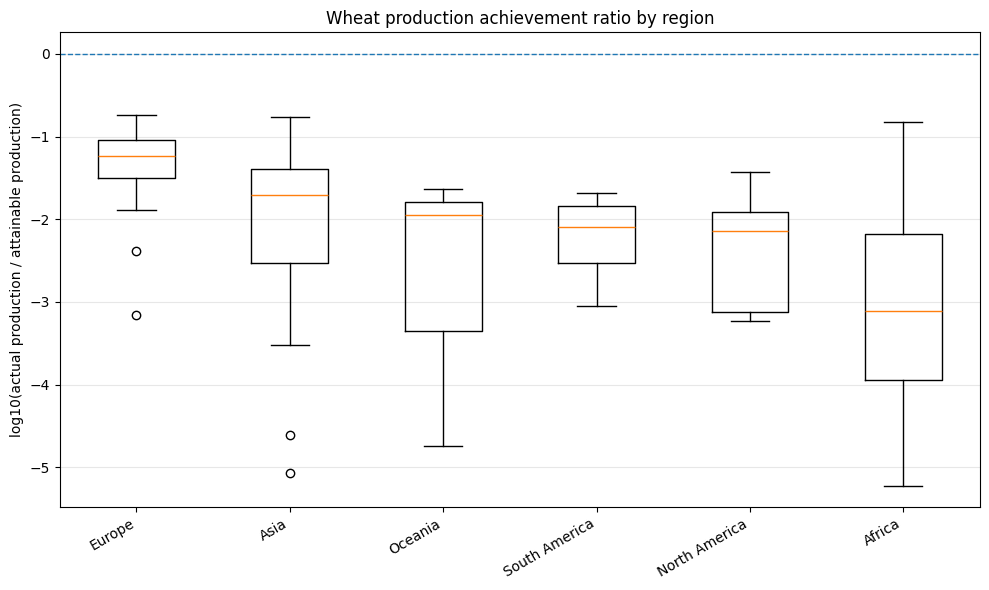

Saved: C:\masterresearch\Comparative_advantage\GAEZ\wheat\country_attainable_production\wheat_actual_div_attainable_by_region_2024_boxplot.png


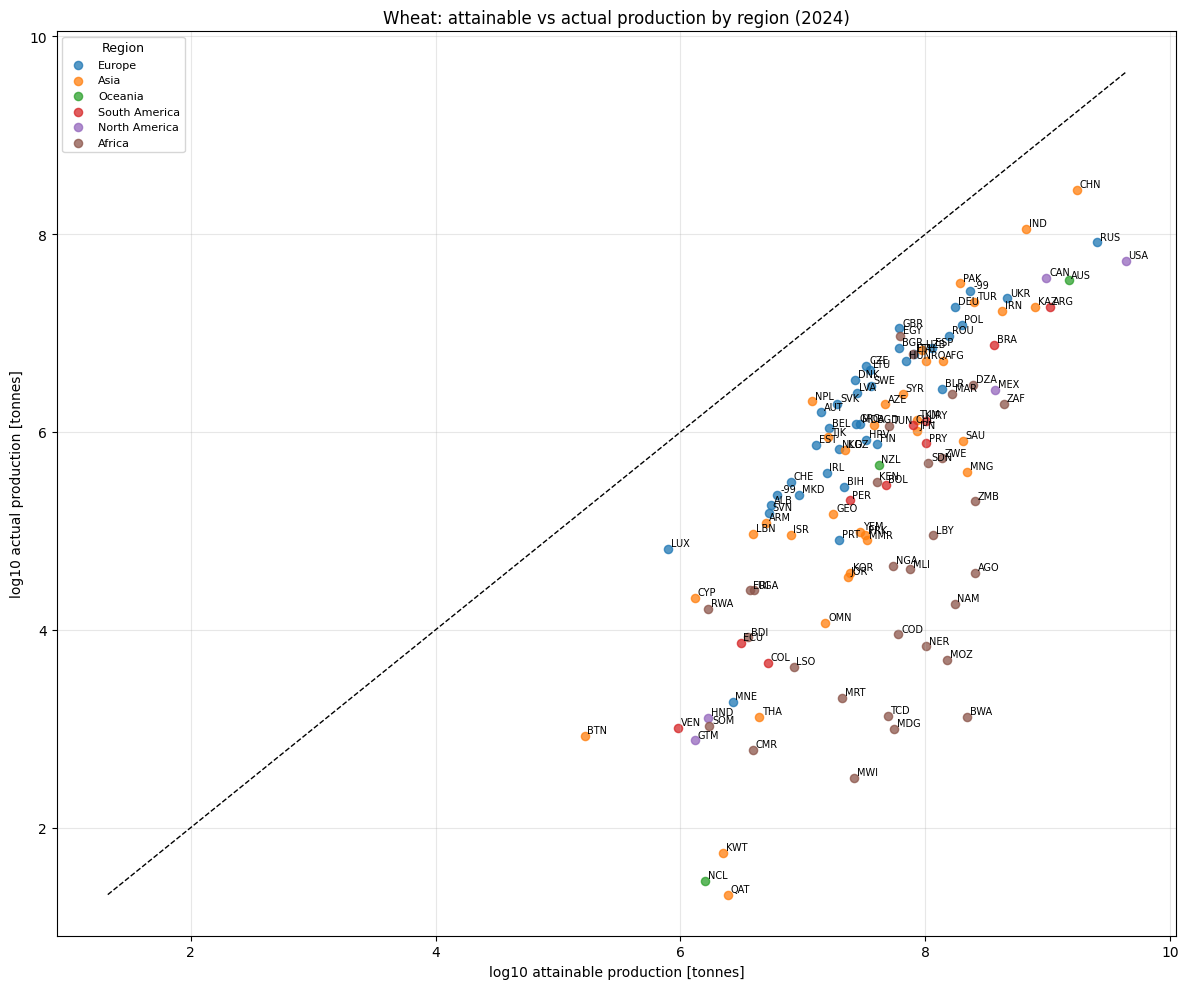

Saved: C:\masterresearch\Comparative_advantage\GAEZ\wheat\country_attainable_production\wheat_attainable_vs_actual_2024_scatter_by_region_labeled.png
                            OLS Regression Results                            
Dep. Variable:             log_actual   R-squared:                       0.700
Model:                            OLS   Adj. R-squared:                  0.684
Method:                 Least Squares   F-statistic:                     48.39
Date:                Thu, 09 Jul 2026   Prob (F-statistic):           9.00e-29
Time:                        15:50:07   Log-Likelihood:                -144.68
No. Observations:                 118   AIC:                             303.4
Df Residuals:                     111   BIC:                             322.7
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                                 coef    std err          z 

,country,iso_a3,region,log_actual,pred_log_actual,residual_log_actual,actual_div_attainable
47,Egypt,EGY,Africa,6.973128,4.777495,2.195633,0.150724
42,Ethiopia,ETH,Africa,6.791364,4.921504,1.869860,0.077778
110,Rwanda,RWA,Africa,4.215283,2.640916,1.574367,0.009694
53,Tunisia,TUN,Africa,6.060698,4.654668,1.406030,0.022688
89,Nepal,NPL,Asia,6.308684,4.904574,1.404110,0.172188
103,Eritrea,ERI,Africa,4.397940,3.104510,1.293430,0.006750
100,Uganda,UGA,Africa,4.397940,3.150295,1.247645,0.006248
25,Morocco,MAR,Africa,6.387687,5.353588,1.034099,0.014806
59,Kenya,KEN,Africa,5.494433,4.514321,0.980112,0.007805
22,Pakistan,PAK,Asia,7.502624,6.556681,0.945943,0.165543


,country,iso_a3,region,log_actual,pred_log_actual,residual_log_actual,actual_div_attainable
107,Qatar,QAT,Asia,1.322219,3.972011,-2.649792,0.000009
18,Botswana,BWA,Africa,3.123211,5.525879,-2.402668,0.000006
108,Kuwait,KWT,Asia,1.742175,3.912711,-2.170536,0.000025
72,Malawi,MWI,Africa,2.506072,4.260340,-1.754268,0.000012
51,Madagascar,MDG,Africa,3.000000,4.706023,-1.706023,0.000018
27,Mozambique,MOZ,Africa,3.698970,5.299563,-1.600593,0.000033
54,Chad,TCD,Africa,3.131298,4.638844,-1.507546,0.000027
112,New Caledonia,NCL,Oceania,1.459694,2.894361,-1.434667,0.000018
106,Montenegro,MNE,Europe,3.271934,4.688824,-1.416890,0.000701
35,Niger,NER,Africa,3.832700,5.063354,-1.230654,0.000067


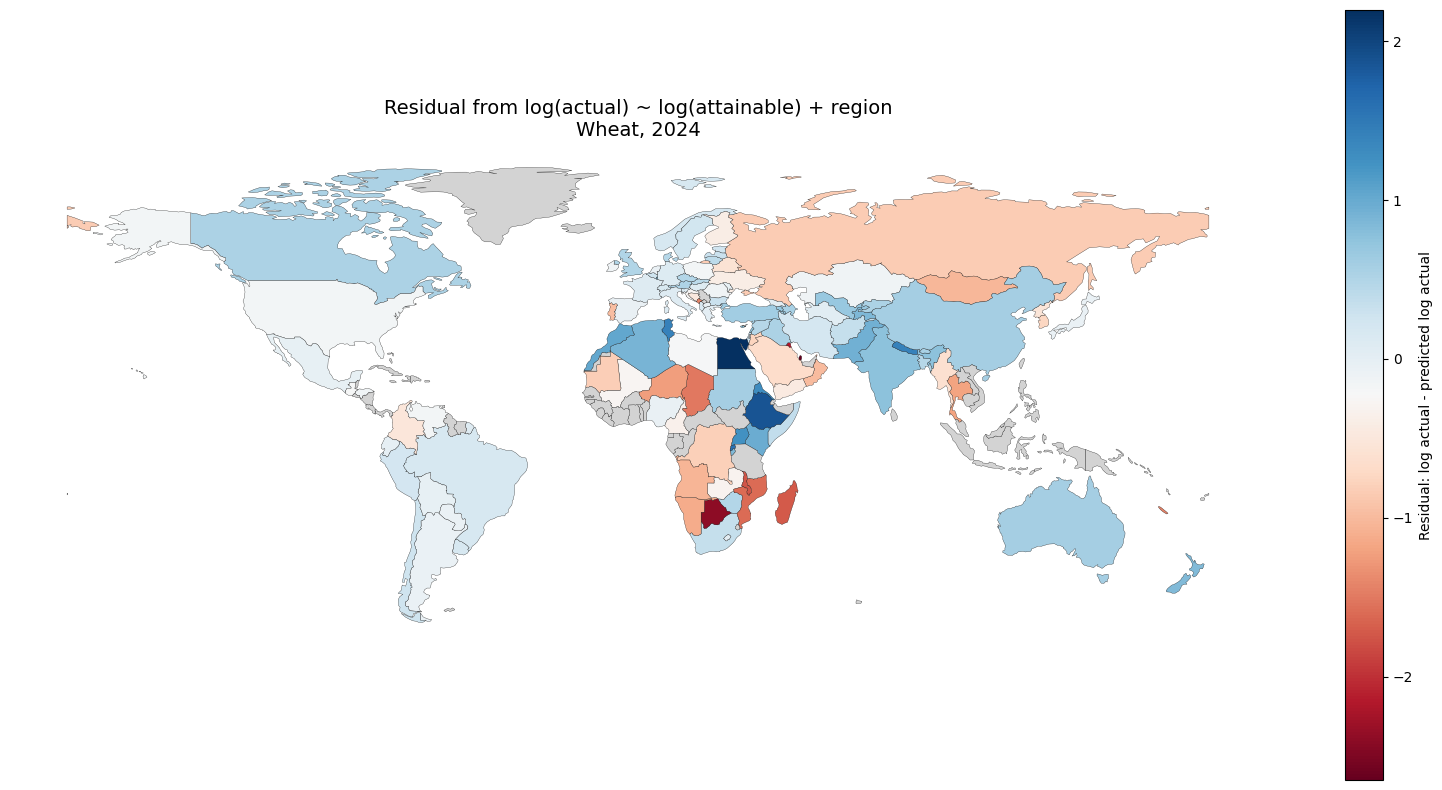

Saved: C:\masterresearch\Comparative_advantage\GAEZ\wheat\country_attainable_production\wheat_residual_log_actual_region_model_2024_map.png


In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# statsmodels がなければ：
# pip install statsmodels

import statsmodels.api as sm
import statsmodels.formula.api as smf

# ============================================================
# 前提：
# df_plot がすでにある
# columns:
# country, iso_a3, log_attainable, log_actual,
# attainable_production_tonnes, actual_production_tonnes, region
# ============================================================

df_analysis = df_plot.copy()

# ============================================================
# 1. 達成率を計算
# ============================================================
df_analysis["actual_div_attainable"] = (
    df_analysis["actual_production_tonnes"]
    / df_analysis["attainable_production_tonnes"]
)

df_analysis["log_actual_div_attainable"] = np.log10(
    df_analysis["actual_div_attainable"]
)

df_analysis = df_analysis[
    np.isfinite(df_analysis["actual_div_attainable"])
    & np.isfinite(df_analysis["log_actual_div_attainable"])
    & (df_analysis["actual_div_attainable"] > 0)
].copy()

print("Number of countries:", len(df_analysis))

display(
    df_analysis[[
        "country",
        "iso_a3",
        "region",
        "actual_production_tonnes",
        "attainable_production_tonnes",
        "actual_div_attainable",
        "log_actual_div_attainable"
    ]].sort_values("actual_div_attainable", ascending=False).head(30)
)

# ============================================================
# 2. 地域別の達成率 summary
# ============================================================
region_summary = df_analysis.groupby("region").agg(
    n=("country", "count"),
    mean_ratio=("actual_div_attainable", "mean"),
    median_ratio=("actual_div_attainable", "median"),
    mean_log_ratio=("log_actual_div_attainable", "mean"),
    median_log_ratio=("log_actual_div_attainable", "median")
).sort_values("median_ratio", ascending=False)

display(region_summary)

# ============================================================
# 3. 地域別 boxplot
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

regions_order = (
    df_analysis.groupby("region")["log_actual_div_attainable"]
    .median()
    .sort_values(ascending=False)
    .index
)

data_to_plot = [
    df_analysis.loc[df_analysis["region"] == r, "log_actual_div_attainable"]
    for r in regions_order
]

ax.boxplot(
    data_to_plot,
    labels=regions_order,
    showfliers=True
)

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_ylabel("log10(actual production / attainable production)")
ax.set_title("Wheat production achievement ratio by region")
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()

out_boxplot = os.path.join(
    output_dir,
    f"wheat_actual_div_attainable_by_region_{target_year}_boxplot.png"
)

plt.savefig(out_boxplot, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_boxplot)

# ============================================================
# 4. 地域別 scatter：45度線からの距離を見る
# ============================================================
fig, ax = plt.subplots(figsize=(12, 10))

for region in regions_order:
    sub = df_analysis[df_analysis["region"] == region]
    ax.scatter(
        sub["log_attainable"],
        sub["log_actual"],
        s=35,
        alpha=0.75,
        label=region
    )

min_val = min(df_analysis["log_attainable"].min(), df_analysis["log_actual"].min())
max_val = max(df_analysis["log_attainable"].max(), df_analysis["log_actual"].max())

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    "--",
    linewidth=1,
    color="black"
)

for _, row in df_analysis.iterrows():
    ax.annotate(
        row["iso_a3"],
        (row["log_attainable"], row["log_actual"]),
        xytext=(2, 2),
        textcoords="offset points",
        fontsize=7
    )

ax.set_xlabel("log10 attainable production [tonnes]")
ax.set_ylabel("log10 actual production [tonnes]")
ax.set_title(
    f"Wheat: attainable vs actual production by region ({target_year})"
)

ax.grid(alpha=0.3)
ax.legend(title="Region", fontsize=8, title_fontsize=9)

plt.tight_layout()

out_scatter_region = os.path.join(
    output_dir,
    f"wheat_attainable_vs_actual_{target_year}_scatter_by_region_labeled.png"
)

plt.savefig(out_scatter_region, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_scatter_region)

# ============================================================
# 5. 回帰1：
#    log(actual) = log(attainable) + region
# ============================================================
reg_df = df_analysis[
    [
        "log_actual",
        "log_attainable",
        "region",
        "country",
        "iso_a3"
    ]
].dropna().copy()

model1 = smf.ols(
    "log_actual ~ log_attainable + C(region)",
    data=reg_df
).fit(cov_type="HC3")

print(model1.summary())

# ============================================================
# 6. 回帰2：
#    log(actual / attainable) = region
# ============================================================
model2 = smf.ols(
    "log_actual_div_attainable ~ C(region)",
    data=df_analysis
).fit(cov_type="HC3")

print(model2.summary())

# ============================================================
# 7. 回帰残差を計算
#    正：予測より多く作っている
#    負：予測より少なく作っている
# ============================================================
df_analysis["pred_log_actual"] = model1.predict(reg_df)
df_analysis["residual_log_actual"] = (
    df_analysis["log_actual"] - df_analysis["pred_log_actual"]
)

display(
    df_analysis[[
        "country",
        "iso_a3",
        "region",
        "log_actual",
        "pred_log_actual",
        "residual_log_actual",
        "actual_div_attainable"
    ]].sort_values("residual_log_actual", ascending=False).head(20)
)

display(
    df_analysis[[
        "country",
        "iso_a3",
        "region",
        "log_actual",
        "pred_log_actual",
        "residual_log_actual",
        "actual_div_attainable"
    ]].sort_values("residual_log_actual", ascending=True).head(20)
)

# ============================================================
# 8. 残差を地図化
# ============================================================
world_resid = world.merge(
    df_analysis[["country", "residual_log_actual"]],
    left_on="ADMIN",
    right_on="country",
    how="left"
)

fig, ax = plt.subplots(figsize=(16, 8))

world_resid.plot(
    column="residual_log_actual",
    cmap="RdBu",
    legend=True,
    ax=ax,
    edgecolor="black",
    linewidth=0.2,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    },
    legend_kwds={
        "label": "Residual: log actual - predicted log actual"
    }
)

ax.set_title(
    f"Residual from log(actual) ~ log(attainable) + region\nWheat, {target_year}",
    fontsize=14
)

ax.axis("off")
plt.tight_layout()

out_resid_map = os.path.join(
    output_dir,
    f"wheat_residual_log_actual_region_model_{target_year}_map.png"
)

plt.savefig(out_resid_map, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_resid_map)

## GDP percapitaをたしてみる

In [18]:
import statsmodels.formula.api as smf

model = smf.ols(
    "log_actual ~ log_attainable + log_gdp",
    data=plot_df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             log_actual   R-squared:                       0.578
Model:                            OLS   Adj. R-squared:                  0.570
Method:                 Least Squares   F-statistic:                     71.33
Date:                Thu, 09 Jul 2026   Prob (F-statistic):           3.14e-20
Time:                        15:54:54   Log-Likelihood:                -146.73
No. Observations:                 107   AIC:                             299.5
Df Residuals:                     104   BIC:                             307.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -8.3481      1.188     -7.

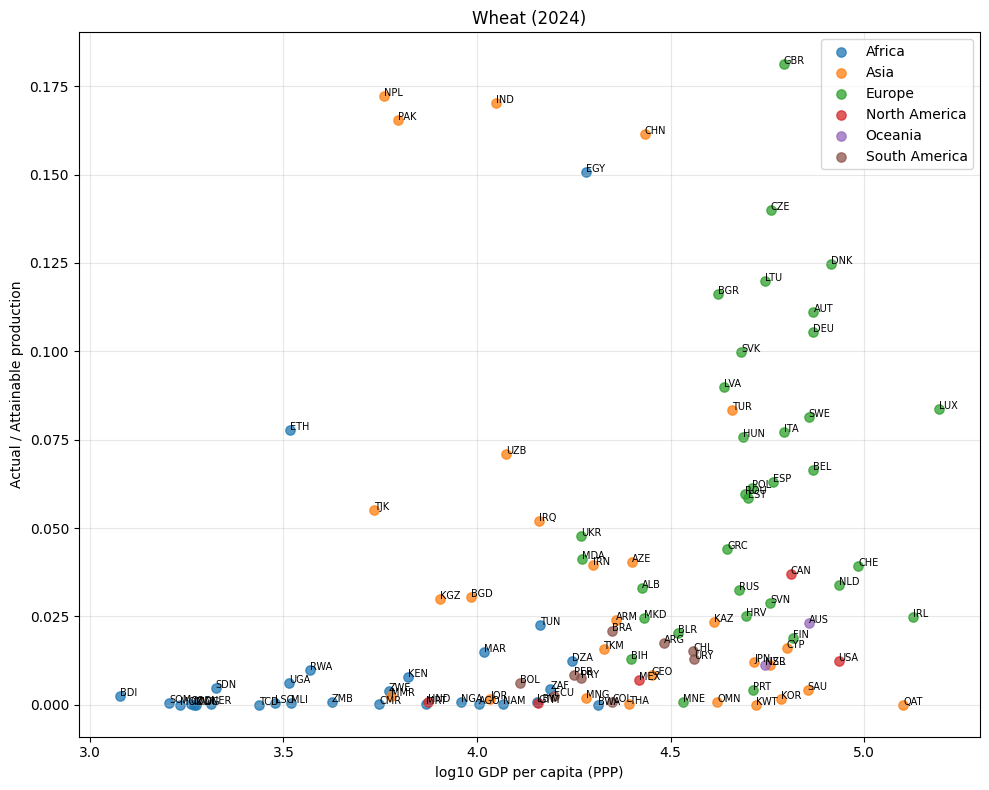

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# GDP per capita (PPP)
# ===============================
gdp = pd.read_csv(
    r"C:\masterresearch\Comparative_advantage\GDP_percapitaPPP.csv",
    skiprows=4
)

gdp = gdp[["Country Code", "2024"]].rename(columns={
    "Country Code": "iso_a3",
    "2024": "GDP_PPP"
})

gdp["GDP_PPP"] = pd.to_numeric(gdp["GDP_PPP"], errors="coerce")

# ===============================
# merge
# ===============================
plot_df = df_plot.merge(
    gdp,
    on="iso_a3",
    how="left"
)

plot_df = plot_df.dropna(subset=["GDP_PPP"]).copy()

plot_df["log_gdp"] = np.log10(plot_df["GDP_PPP"])

# ===============================
# Actual / Attainable
# ===============================

plot_df["attainment"] = (
    10 ** (plot_df["log_actual"] - plot_df["log_attainable"])
)

# ===============================
# Plot
# ===============================

fig, ax = plt.subplots(figsize=(10,8))

regions = sorted(plot_df["region"].dropna().unique())

for region in regions:

    tmp = plot_df[plot_df["region"] == region]

    ax.scatter(
        tmp["log_gdp"],
        tmp["attainment"],
        s=45,
        alpha=0.75,
        label=region
    )

    for _, r in tmp.iterrows():
        ax.text(
            r["log_gdp"],
            r["attainment"],
            r["iso_a3"],
            fontsize=7
        )

ax.set_xlabel("log10 GDP per capita (PPP)")
ax.set_ylabel("Actual / Attainable production")
ax.set_title(f"Wheat ({target_year})")

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

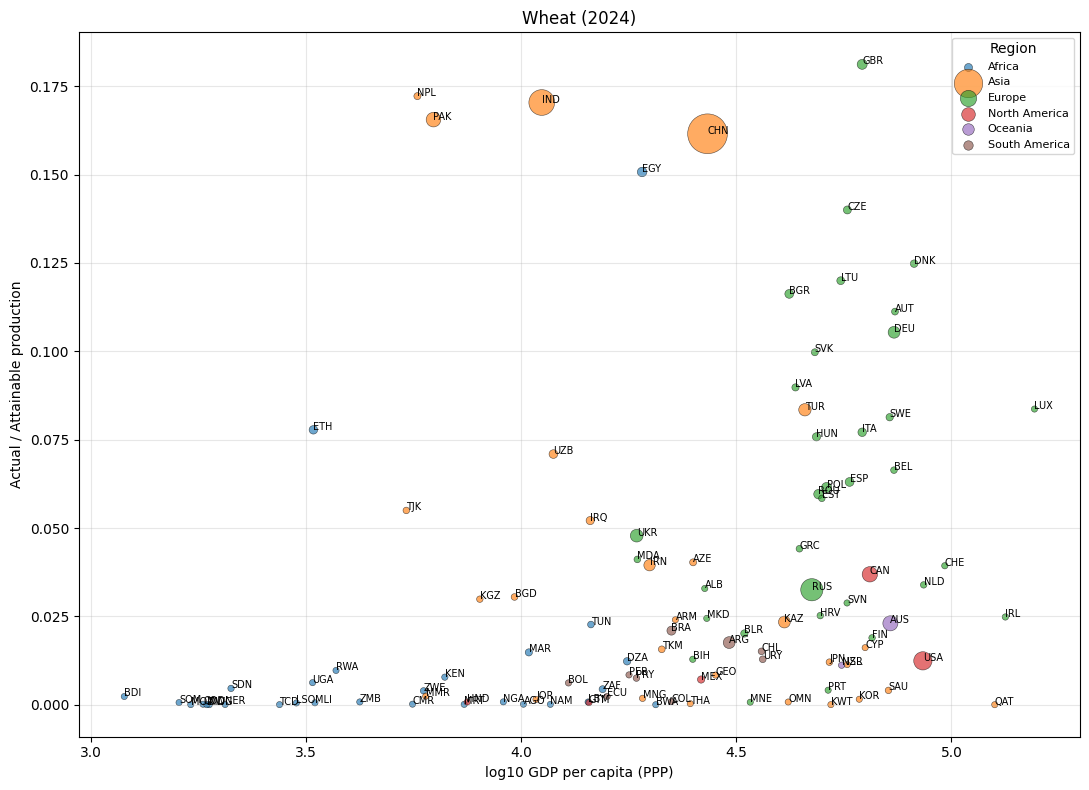

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# GDP per capita (PPP)
# ===============================
gdp = pd.read_csv(
    r"C:\masterresearch\Comparative_advantage\GDP_percapitaPPP.csv",
    skiprows=4
)

gdp = gdp[["Country Code", "2024"]].rename(columns={
    "Country Code": "iso_a3",
    "2024": "GDP_PPP"
})

gdp["GDP_PPP"] = pd.to_numeric(gdp["GDP_PPP"], errors="coerce")

# ===============================
# merge
# ===============================
plot_df = df_plot.merge(
    gdp,
    on="iso_a3",
    how="left"
)

plot_df = plot_df.dropna(subset=["GDP_PPP"]).copy()

plot_df["log_gdp"] = np.log10(plot_df["GDP_PPP"])

# ===============================
# Actual / Attainable
# ===============================
plot_df["attainment"] = 10 ** (
    plot_df["log_actual"] - plot_df["log_attainable"]
)

# ===============================
# Marker size: 実生産量に面積比例
# ===============================
plot_df["actual_prod"] = 10 ** plot_df["log_actual"]

# matplotlib の s は「点の面積」なので、ここは実生産量に比例
plot_df["marker_size"] = (
    20 + 800 * plot_df["actual_prod"] / plot_df["actual_prod"].max()
)

# ===============================
# Plot
# ===============================
fig, ax = plt.subplots(figsize=(11, 8))

regions = sorted(plot_df["region"].dropna().unique())

for region in regions:
    tmp = plot_df[plot_df["region"] == region]

    ax.scatter(
        tmp["log_gdp"],
        tmp["attainment"],
        s=tmp["marker_size"],
        alpha=0.65,
        label=region,
        edgecolor="black",
        linewidth=0.4
    )

    for _, r in tmp.iterrows():
        ax.text(
            r["log_gdp"],
            r["attainment"],
            r["iso_a3"],
            fontsize=7
        )

ax.set_xlabel("log10 GDP per capita (PPP)")
ax.set_ylabel("Actual / Attainable production")
ax.set_title(f"Wheat ({target_year})")

ax.grid(True, alpha=0.3)
ax.legend(title="Region", fontsize=8)

plt.tight_layout()
plt.show()

## croplandデータHYDE3.4

In [ ]:
import xarray as xr

path = r"C:\masterresearch\Comparative_advantage\HYDE3.4\cropland.nc"

ds = xr.open_dataset(path)

print(ds)
print("\n次元:")
print(ds.sizes)

print("\n座標:")
print(ds.coords)

print("\n変数:")
for name, da in ds.data_vars.items():
    print(name, da.dims, da.shape, da.attrs)

使用する時点: 2024-05-01 00:00:00
<xarray.DataArray 'cropland' (lat: 2160, lon: 4320)> Size: 37MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(2160, 4320), dtype=float32)
Coordinates:
  * lat      (lat) float32 9kB 89.96 89.87 89.79 89.71 ... -89.79 -89.88 -89.96
  * lon      (lon) float32 17kB -180.0 -179.9 -179.8 ... 179.8 179.9 180.0
    time     object 8B 2024-05-01 00:00:00
Attributes:
    standard_name:  cropland
    long_name:      Area cropland
    units:          km**2
最小値: 0.0
最大値: 85.86329650878906
単位: km**2

Cropland fraction
最小値: 0.0
最大値: 1.0000732307229014
平均値: 0.10254605199186491


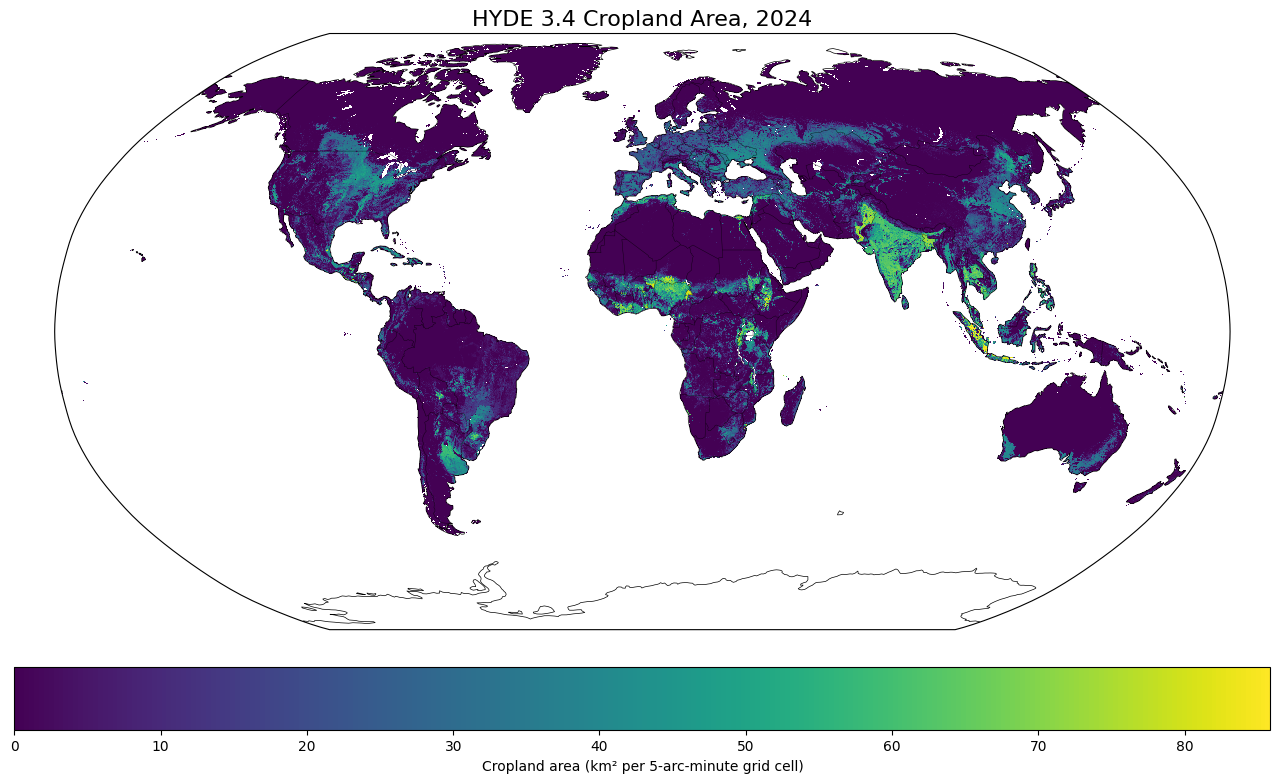

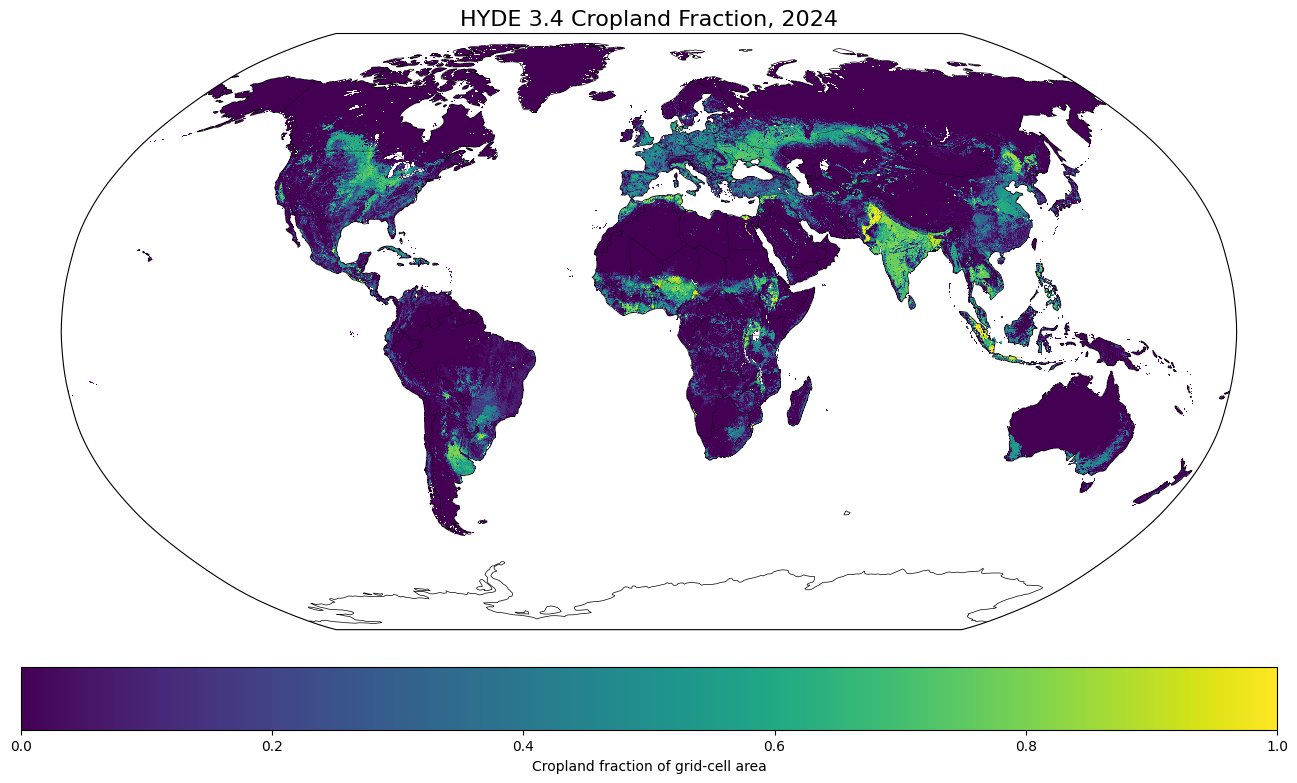

c:\Users\tsuda\AppData\Local\Programs\Python\Python313\Lib\site-packages\xarray\coding\times.py:215: SerializationWarning: Ambiguous reference date string: 1-5-1 00:00:00. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-5-1 00:00:00). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)



保存しました:
C:\Users\tsuda\Downloads\hyde_cropland_fraction_2024.nc


In [2]:
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# ============================================================
# 1. ファイルパス
# ============================================================
NC_PATH = Path(r"C:\Users\tsuda\Downloads\cropland.nc")

if not NC_PATH.exists():
    raise FileNotFoundError(f"ファイルが見つかりません: {NC_PATH}")


# ============================================================
# 2. データを開く
#
# 5 GBあるので、全時点をloadしない
# ============================================================
ds = xr.open_dataset(
    NC_PATH,
    decode_times=True,
    mask_and_scale=True,
)


# ============================================================
# 3. 2024年のtime indexを探す
#
# timeがcftime型でも動くように、year属性から抽出する
# ============================================================
years = np.array([t.year for t in ds["time"].values])

indices_2024 = np.where(years == 2024)[0]

if len(indices_2024) == 0:
    raise ValueError("2024年のデータが見つかりません。")

time_index = int(indices_2024[0])

print("使用する時点:", ds["time"].values[time_index])


# 2024年だけ取り出してメモリに読み込む
crop_area_2024 = ds["cropland"].isel(time=time_index).load()

print(crop_area_2024)
print("最小値:", float(crop_area_2024.min(skipna=True)))
print("最大値:", float(crop_area_2024.max(skipna=True)))
print("単位:", crop_area_2024.attrs.get("units"))


# ============================================================
# 4. 各グリッドの面積を計算
#
# 球面上の緯度経度グリッド面積:
#
# A = R² × Δλ × (sin φ_north - sin φ_south)
#
# 単位はkm²
# ============================================================
lat = ds["lat"].values.astype(float)
lon = ds["lon"].values.astype(float)

earth_radius_km = 6371.0088


def coordinate_edges(values):
    """
    セル中心座標からセル境界座標を計算する。
    昇順・降順の両方に対応。
    """
    values = np.asarray(values, dtype=float)

    edges = np.empty(values.size + 1, dtype=float)
    edges[1:-1] = (values[:-1] + values[1:]) / 2

    edges[0] = values[0] - (values[1] - values[0]) / 2
    edges[-1] = values[-1] + (values[-1] - values[-2]) / 2

    return edges


lat_edges = coordinate_edges(lat)
lon_edges = coordinate_edges(lon)

# 緯度は±90度以内にする
lat_edges = np.clip(lat_edges, -90.0, 90.0)

lat_edges_rad = np.deg2rad(lat_edges)
lon_edges_rad = np.deg2rad(lon_edges)

# 各緯度帯の面積要素
lat_factor = np.abs(
    np.sin(lat_edges_rad[1:])
    - np.sin(lat_edges_rad[:-1])
)

# 各経度セルの幅
lon_width = np.abs(
    lon_edges_rad[1:]
    - lon_edges_rad[:-1]
)

# 2160 × 4320 のグリッド面積
grid_area_km2 = (
    earth_radius_km**2
    * lat_factor[:, np.newaxis]
    * lon_width[np.newaxis, :]
)

grid_area = xr.DataArray(
    grid_area_km2,
    coords={
        "lat": ds["lat"],
        "lon": ds["lon"],
    },
    dims=("lat", "lon"),
    name="grid_area",
    attrs={"units": "km**2"},
)


# ============================================================
# 5. Cropland fractionを計算
# ============================================================
cropland_fraction_2024 = crop_area_2024 / grid_area

# 浮動小数点誤差や特殊値を処理
cropland_fraction_2024 = cropland_fraction_2024.where(
    np.isfinite(cropland_fraction_2024)
)

# 通常は0〜1のはず。
# わずかな計算誤差がある場合に備えて表示用にはclipする。
cropland_fraction_plot = cropland_fraction_2024.clip(min=0, max=1)

print("\nCropland fraction")
print("最小値:", float(cropland_fraction_2024.min(skipna=True)))
print("最大値:", float(cropland_fraction_2024.max(skipna=True)))
print("平均値:", float(cropland_fraction_2024.mean(skipna=True)))


# ============================================================
# 6. 2024年 Cropland面積を全球表示
# ============================================================
fig = plt.figure(figsize=(16, 8))
ax = plt.axes(projection=ccrs.Robinson())

mesh = ax.pcolormesh(
    lon,
    lat,
    crop_area_2024,
    transform=ccrs.PlateCarree(),
    shading="auto",
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.25)
ax.set_global()

cbar = plt.colorbar(
    mesh,
    ax=ax,
    orientation="horizontal",
    pad=0.05,
    shrink=0.8,
)

cbar.set_label("Cropland area (km² per 5-arc-minute grid cell)")

ax.set_title(
    "HYDE 3.4 Cropland Area, 2024",
    fontsize=16,
)

plt.tight_layout()
plt.show()


# ============================================================
# 7. 2024年 Cropland fractionを全球表示
# ============================================================
fig = plt.figure(figsize=(16, 8))
ax = plt.axes(projection=ccrs.Robinson())

mesh = ax.pcolormesh(
    lon,
    lat,
    cropland_fraction_plot,
    transform=ccrs.PlateCarree(),
    shading="auto",
    vmin=0,
    vmax=1,
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.25)
ax.set_global()

cbar = plt.colorbar(
    mesh,
    ax=ax,
    orientation="horizontal",
    pad=0.05,
    shrink=0.8,
)

cbar.set_label("Cropland fraction of grid-cell area")

ax.set_title(
    "HYDE 3.4 Cropland Fraction, 2024",
    fontsize=16,
)

plt.tight_layout()
plt.show()


# ============================================================
# 8. 必要ならGeoTIFF等に使える形で保存
# ============================================================
output_nc = NC_PATH.parent / "hyde_cropland_fraction_2024.nc"

cropland_fraction_2024.name = "cropland_fraction"
cropland_fraction_2024.attrs = {
    "long_name": "Fraction of grid-cell area classified as cropland",
    "units": "1",
    "year": 2024,
}

cropland_fraction_2024.to_netcdf(output_nc)

print("\n保存しました:")
print(output_nc)


ds.close()

In [3]:
from pathlib import Path
import json

import numpy as np
import xarray as xr
from numpy.lib.format import open_memmap


# ============================================================
# 1. パス設定
# ============================================================

# cropland.nc の実際の保存場所に修正してください
INPUT_NC = Path(
    r"C:\Users\tsuda\Downloads\cropland.nc"
)

OUTPUT_DIR = Path(
    r"C:\masterresearch\Comparative_advantage\HYDE3.4\cropland_npys"
)

YEARLY_DIR = OUTPUT_DIR / "yearly"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
YEARLY_DIR.mkdir(parents=True, exist_ok=True)

if not INPUT_NC.exists():
    raise FileNotFoundError(
        f"入力ファイルが見つかりません:\n{INPUT_NC}"
    )


# ============================================================
# 2. 設定
# ============================================================

START_YEAR = 1950

# Noneなら、NetCDF内の最新年まで自動的に使用
REQUESTED_END_YEAR = None

# True:
#   全年を1つの巨大なnpyにも保存する
#
# False:
#   1年ごとのnpyだけ保存する
SAVE_STACKED_NPY = True

# True:
#   1年ごとのnpyも保存する
SAVE_YEARLY_NPY = True

# fractionを0～1に制限する
CLIP_FRACTION = True

# 出力型
# float32なら1950～2024の全球データで約2.8 GB
OUTPUT_DTYPE = np.float32


# ============================================================
# 3. 補助関数
# ============================================================

def coordinate_edges(values: np.ndarray) -> np.ndarray:
    """
    セル中心座標からセル境界座標を計算する。
    昇順・降順の両方に対応する。
    """
    values = np.asarray(values, dtype=np.float64)

    if values.ndim != 1:
        raise ValueError("座標は1次元である必要があります。")

    if values.size < 2:
        raise ValueError("座標点が2個以上必要です。")

    edges = np.empty(values.size + 1, dtype=np.float64)

    edges[1:-1] = (values[:-1] + values[1:]) / 2.0
    edges[0] = values[0] - (values[1] - values[0]) / 2.0
    edges[-1] = values[-1] + (values[-1] - values[-2]) / 2.0

    return edges


def extract_year(time_value) -> int:
    """
    numpy datetime64、datetime、cftimeなどから年を取得する。
    """
    if hasattr(time_value, "year"):
        return int(time_value.year)

    text = str(time_value)
    return int(text.split("-")[0])


def calculate_grid_area_km2(
    lat: np.ndarray,
    lon: np.ndarray,
    earth_radius_km: float = 6371.0088
) -> np.ndarray:
    """
    緯度経度グリッドの面積を球面近似で計算する。

    戻り値:
        shape = (lat, lon)
        units = km²
    """
    lat_edges = coordinate_edges(lat)
    lon_edges = coordinate_edges(lon)

    lat_edges = np.clip(lat_edges, -90.0, 90.0)

    lat_edges_rad = np.deg2rad(lat_edges)
    lon_edges_rad = np.deg2rad(lon_edges)

    lat_factor = np.abs(
        np.sin(lat_edges_rad[1:])
        - np.sin(lat_edges_rad[:-1])
    )

    lon_width = np.abs(
        lon_edges_rad[1:]
        - lon_edges_rad[:-1]
    )

    area = (
        earth_radius_km ** 2
        * lat_factor[:, np.newaxis]
        * lon_width[np.newaxis, :]
    )

    return area.astype(np.float32)


# ============================================================
# 4. NetCDFを開く
# ============================================================

ds = xr.open_dataset(
    INPUT_NC,
    decode_times=True,
    mask_and_scale=True,
)

required_items = {"time", "lat", "lon", "cropland"}

missing_items = required_items.difference(
    set(ds.variables) | set(ds.coords)
)

if missing_items:
    ds.close()
    raise KeyError(
        f"必要な変数・座標がありません: {missing_items}"
    )


# ============================================================
# 5. 年・座標を確認
# ============================================================

time_values = ds["time"].values
all_years = np.array(
    [extract_year(value) for value in time_values],
    dtype=np.int32
)

latest_year_in_file = int(all_years.max())

if REQUESTED_END_YEAR is None:
    end_year = latest_year_in_file
else:
    end_year = min(
        int(REQUESTED_END_YEAR),
        latest_year_in_file
    )

selected_indices = np.where(
    (all_years >= START_YEAR)
    & (all_years <= end_year)
)[0]

if selected_indices.size == 0:
    ds.close()
    raise ValueError(
        f"{START_YEAR}～{end_year}年のデータがありません。"
    )

selected_years = all_years[selected_indices]

print("=" * 70)
print("抽出期間")
print("=" * 70)
print(f"開始年         : {START_YEAR}")
print(f"終了年         : {end_year}")
print(f"ファイル最新年 : {latest_year_in_file}")
print(f"抽出年数       : {selected_years.size}")
print(f"抽出年         : {selected_years}")


# ============================================================
# 6. 年の欠落を確認
# ============================================================

expected_years = np.arange(
    START_YEAR,
    end_year + 1,
    dtype=np.int32
)

missing_years = np.setdiff1d(
    expected_years,
    selected_years
)

if missing_years.size > 0:
    print("\n注意：以下の年はNetCDFに存在しません。")
    print(missing_years)
    print("存在する年だけを保存します。")
else:
    print("\n1950年から最新年まで、毎年のデータがあります。")


# ============================================================
# 7. 座標とグリッド面積を保存
# ============================================================

lat = ds["lat"].values.astype(np.float32)
lon = ds["lon"].values.astype(np.float32)

n_years = selected_years.size
n_lat = lat.size
n_lon = lon.size

print("\n配列サイズ")
print(f"年   : {n_years}")
print(f"緯度 : {n_lat}")
print(f"経度 : {n_lon}")

grid_area_km2 = calculate_grid_area_km2(
    lat=lat,
    lon=lon
)

np.save(
    OUTPUT_DIR / "years.npy",
    selected_years
)

np.save(
    OUTPUT_DIR / "lat.npy",
    lat
)

np.save(
    OUTPUT_DIR / "lon.npy",
    lon
)

np.save(
    OUTPUT_DIR / "grid_area_km2.npy",
    grid_area_km2
)


# ============================================================
# 8. 全年をまとめるnpyを作成
#
# open_memmapを使うことで、
# 約2.8 GBの配列をRAM上に一括作成しない。
# ============================================================

stacked_path = (
    OUTPUT_DIR
    / f"cropland_fraction_{selected_years[0]}_{selected_years[-1]}.npy"
)

stacked_array = None

if SAVE_STACKED_NPY:
    stacked_array = open_memmap(
        stacked_path,
        mode="w+",
        dtype=OUTPUT_DTYPE,
        shape=(n_years, n_lat, n_lon)
    )

    print("\nまとめnpy:")
    print(stacked_path)
    print(
        "予想ファイルサイズ:",
        f"{stacked_array.nbytes / 1024**3:.2f} GB"
    )


# ============================================================
# 9. 1年ずつ読み込み、fractionに変換して保存
# ============================================================

summary_records = []

for output_index, (
    source_index,
    year
) in enumerate(
    zip(selected_indices, selected_years),
    start=0
):
    print(
        f"\n[{output_index + 1:02d}/{n_years}] "
        f"{year}年を処理中..."
    )

    # その年だけ読み込む
    crop_area = (
        ds["cropland"]
        .isel(time=int(source_index))
        .values
        .astype(np.float32)
    )

    # 不正値をNaNにする
    crop_area[~np.isfinite(crop_area)] = np.nan

    # 負のcropland面積は無効として0へ
    crop_area = np.where(
        crop_area < 0,
        0,
        crop_area
    ).astype(np.float32)

    # km² / km² = fraction
    with np.errstate(
        divide="ignore",
        invalid="ignore"
    ):
        fraction = crop_area / grid_area_km2

    fraction = fraction.astype(OUTPUT_DTYPE)

    fraction[~np.isfinite(fraction)] = np.nan

    if CLIP_FRACTION:
        fraction = np.clip(
            fraction,
            0.0,
            1.0
        ).astype(OUTPUT_DTYPE)

    # 年別npy
    if SAVE_YEARLY_NPY:
        yearly_path = (
            YEARLY_DIR
            / f"cropland_fraction_{year}.npy"
        )

        np.save(
            yearly_path,
            fraction
        )

    # 全年まとめnpy
    if stacked_array is not None:
        stacked_array[output_index, :, :] = fraction

        # ディスクへ順次書き込む
        stacked_array.flush()

    valid = np.isfinite(fraction)

    if valid.any():
        record = {
            "year": int(year),
            "minimum": float(
                np.nanmin(fraction)
            ),
            "maximum": float(
                np.nanmax(fraction)
            ),
            "mean_unweighted": float(
                np.nanmean(fraction)
            ),
            "cropland_area_km2": float(
                np.nansum(crop_area)
            ),
            "valid_cells": int(
                valid.sum()
            ),
        }
    else:
        record = {
            "year": int(year),
            "minimum": None,
            "maximum": None,
            "mean_unweighted": None,
            "cropland_area_km2": None,
            "valid_cells": 0,
        }

    summary_records.append(record)

    print(
        f"  fraction範囲 : "
        f"{record['minimum']} ～ {record['maximum']}"
    )
    print(
        f"  全球cropland面積 : "
        f"{record['cropland_area_km2']:,.0f} km²"
    )


# memmapを明示的に閉じる
if stacked_array is not None:
    stacked_array.flush()
    del stacked_array


# ============================================================
# 10. メタデータを保存
# ============================================================

metadata = {
    "source_file": str(INPUT_NC),
    "source_dataset": ds.attrs.get(
        "description",
        "HYDE cropland"
    ),
    "hyde_version": ds.attrs.get(
        "version",
        "unknown"
    ),
    "variable_source": "cropland",
    "source_units": ds["cropland"].attrs.get(
        "units",
        "unknown"
    ),
    "output_variable": "cropland_fraction",
    "output_units": "fraction from 0 to 1",
    "start_year": int(selected_years[0]),
    "end_year": int(selected_years[-1]),
    "number_of_years": int(n_years),
    "shape_stacked": [
        int(n_years),
        int(n_lat),
        int(n_lon)
    ],
    "dimension_order": [
        "time",
        "lat",
        "lon"
    ],
    "latitude_order": (
        "north_to_south"
        if lat[0] > lat[-1]
        else "south_to_north"
    ),
    "longitude_order": (
        "west_to_east"
        if lon[0] < lon[-1]
        else "east_to_west"
    ),
    "missing_years": [
        int(year)
        for year in missing_years
    ],
    "clipped_to_0_1": bool(
        CLIP_FRACTION
    ),
    "dtype": str(
        np.dtype(OUTPUT_DTYPE)
    ),
    "stacked_file": (
        stacked_path.name
        if SAVE_STACKED_NPY
        else None
    ),
    "yearly_directory": (
        YEARLY_DIR.name
        if SAVE_YEARLY_NPY
        else None
    ),
}

with open(
    OUTPUT_DIR / "metadata.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        metadata,
        file,
        ensure_ascii=False,
        indent=2
    )


# 年ごとの簡易統計
with open(
    OUTPUT_DIR / "annual_summary.csv",
    "w",
    encoding="utf-8"
) as file:
    file.write(
        "year,minimum,maximum,mean_unweighted,"
        "cropland_area_km2,valid_cells\n"
    )

    for record in summary_records:
        file.write(
            f"{record['year']},"
            f"{record['minimum']},"
            f"{record['maximum']},"
            f"{record['mean_unweighted']},"
            f"{record['cropland_area_km2']},"
            f"{record['valid_cells']}\n"
        )


# ============================================================
# 11. 閉じる
# ============================================================

ds.close()


# ============================================================
# 12. 保存結果を確認
# ============================================================

print("\n" + "=" * 70)
print("保存完了")
print("=" * 70)
print(f"保存先: {OUTPUT_DIR}")

print("\n主なファイル:")
print(OUTPUT_DIR / "years.npy")
print(OUTPUT_DIR / "lat.npy")
print(OUTPUT_DIR / "lon.npy")
print(OUTPUT_DIR / "grid_area_km2.npy")
print(OUTPUT_DIR / "metadata.json")
print(OUTPUT_DIR / "annual_summary.csv")

if SAVE_STACKED_NPY:
    print(stacked_path)

if SAVE_YEARLY_NPY:
    print(YEARLY_DIR)

抽出期間
開始年         : 1950
終了年         : 2024
ファイル最新年 : 2024
抽出年数       : 75
抽出年         : [1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961 1962 1963
 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975 1976 1977
 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991
 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005
 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019
 2020 2021 2022 2023 2024]

1950年から最新年まで、毎年のデータがあります。

配列サイズ
年   : 75
緯度 : 2160
経度 : 4320

まとめnpy:
C:\masterresearch\Comparative_advantage\HYDE3.4\cropland_npys\cropland_fraction_1950_2024.npy
予想ファイルサイズ: 2.61 GB

[01/75] 1950年を処理中...
  fraction範囲 : 0.0 ～ 1.0
  全球cropland面積 : 12,101,653 km²

[02/75] 1951年を処理中...
  fraction範囲 : 0.0 ～ 1.0
  全球cropland面積 : 12,226,836 km²

[03/75] 1952年を処理中...
  fraction範囲 : 0.0 ～ 1.0
  全球cropland面積 : 12,376,439 km²

[04/75] 1953年を処理中...
  fraction範囲 : 0.0 ～ 1.0
  全球cropland面積 : 12,501,137 km²

[05/75] 1954年を処理中...
  fract

In [4]:
import numpy as np

fraction_2024 = np.load(
    r"C:\masterresearch\Comparative_advantage\HYDE3.4"
    r"\cropland_npys\yearly\cropland_fraction_2024.npy"
)

print(fraction_2024.shape)
print(np.nanmin(fraction_2024))
print(np.nanmax(fraction_2024))

(2160, 4320)
0.0
1.0


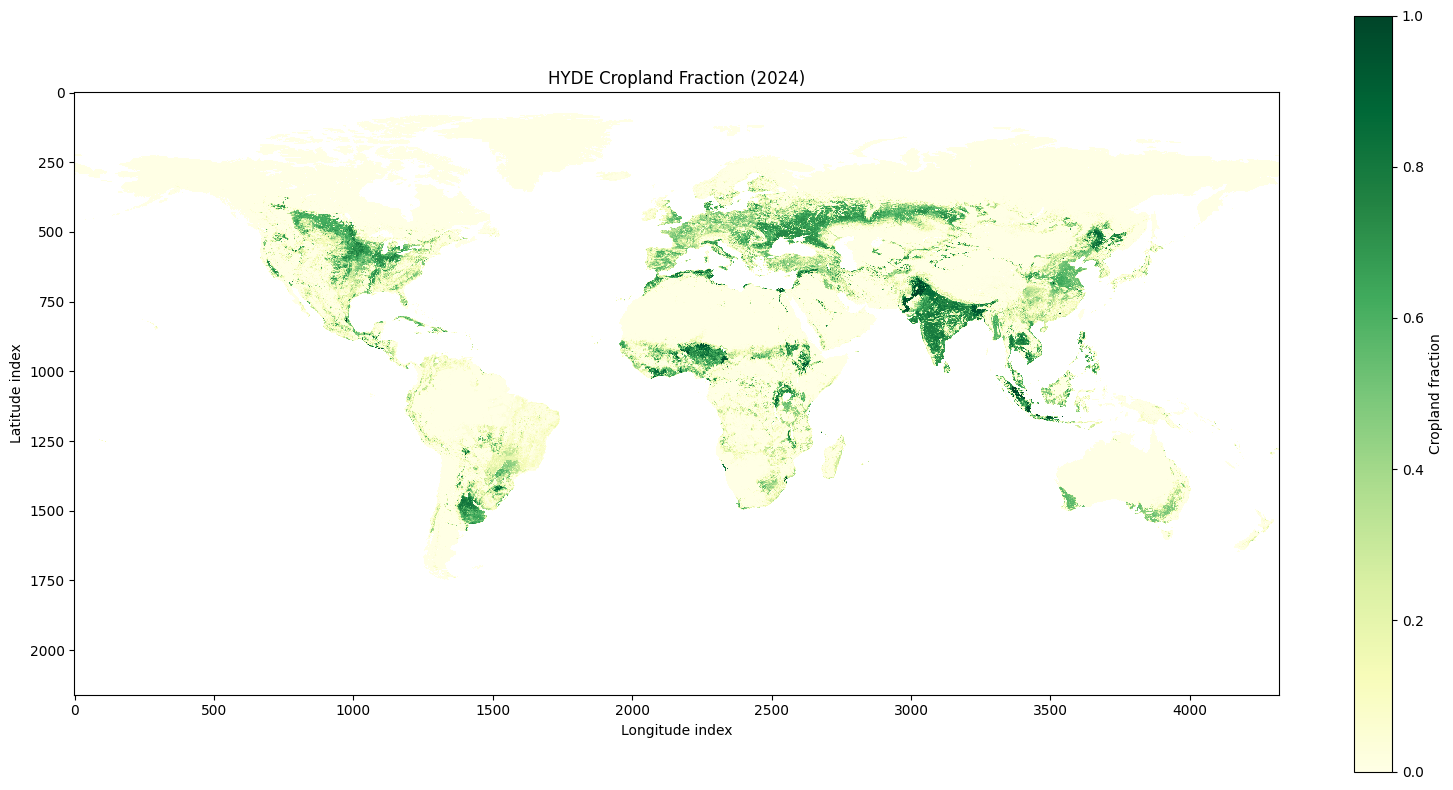

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# 読み込み
# ===============================
fraction_2024 = np.load(
    r"C:\masterresearch\Comparative_advantage\HYDE3.4\cropland_npys\yearly\cropland_fraction_2024.npy"
)

# ===============================
# 描画
# ===============================
plt.figure(figsize=(16, 8))

im = plt.imshow(
    fraction_2024,
    cmap="YlGn",
    vmin=0,
    vmax=1,
    interpolation="nearest",
)

plt.colorbar(im, label="Cropland fraction")
plt.title("HYDE Cropland Fraction (2024)")
plt.xlabel("Longitude index")
plt.ylabel("Latitude index")

plt.tight_layout()
plt.show()

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# statsmodels がなければ：
# pip install statsmodels

import statsmodels.api as sm
import statsmodels.formula.api as smf

# ============================================================
# 前提：
# df_plot がすでにある
# columns:
# country, iso_a3, log_attainable, log_actual,
# attainable_production_tonnes, actual_production_tonnes, region
# ============================================================

df_analysis = df_plot.copy()

# ============================================================
# 1. 達成率を計算
# ============================================================
df_analysis["actual_div_attainable"] = (
    df_analysis["actual_production_tonnes"]
    / df_analysis["attainable_production_tonnes"]
)

df_analysis["log_actual_div_attainable"] = np.log10(
    df_analysis["actual_div_attainable"]
)

df_analysis = df_analysis[
    np.isfinite(df_analysis["actual_div_attainable"])
    & np.isfinite(df_analysis["log_actual_div_attainable"])
    & (df_analysis["actual_div_attainable"] > 0)
].copy()

print("Number of countries:", len(df_analysis))

display(
    df_analysis[[
        "country",
        "iso_a3",
        "region",
        "actual_production_tonnes",
        "attainable_production_tonnes",
        "actual_div_attainable",
        "log_actual_div_attainable"
    ]].sort_values("actual_div_attainable", ascending=False).head(30)
)

# ============================================================
# 2. 地域別の達成率 summary
# ============================================================
region_summary = df_analysis.groupby("region").agg(
    n=("country", "count"),
    mean_ratio=("actual_div_attainable", "mean"),
    median_ratio=("actual_div_attainable", "median"),
    mean_log_ratio=("log_actual_div_attainable", "mean"),
    median_log_ratio=("log_actual_div_attainable", "median")
).sort_values("median_ratio", ascending=False)

display(region_summary)

# ============================================================
# 3. 地域別 boxplot
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

regions_order = (
    df_analysis.groupby("region")["log_actual_div_attainable"]
    .median()
    .sort_values(ascending=False)
    .index
)

data_to_plot = [
    df_analysis.loc[df_analysis["region"] == r, "log_actual_div_attainable"]
    for r in regions_order
]

ax.boxplot(
    data_to_plot,
    labels=regions_order,
    showfliers=True
)

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_ylabel("log10(actual production / attainable production)")
ax.set_title("Wheat production achievement ratio by region")
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()

out_boxplot = os.path.join(
    output_dir,
    f"wheat_actual_div_attainable_by_region_{target_year}_boxplot.png"
)

plt.savefig(out_boxplot, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_boxplot)

# ============================================================
# 4. 地域別 scatter：45度線からの距離を見る
# ============================================================
fig, ax = plt.subplots(figsize=(12, 10))

for region in regions_order:
    sub = df_analysis[df_analysis["region"] == region]
    ax.scatter(
        sub["log_attainable"],
        sub["log_actual"],
        s=35,
        alpha=0.75,
        label=region
    )

min_val = min(df_analysis["log_attainable"].min(), df_analysis["log_actual"].min())
max_val = max(df_analysis["log_attainable"].max(), df_analysis["log_actual"].max())

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    "--",
    linewidth=1,
    color="black"
)

for _, row in df_analysis.iterrows():
    ax.annotate(
        row["iso_a3"],
        (row["log_attainable"], row["log_actual"]),
        xytext=(2, 2),
        textcoords="offset points",
        fontsize=7
    )

ax.set_xlabel("log10 attainable production [tonnes]")
ax.set_ylabel("log10 actual production [tonnes]")
ax.set_title(
    f"Wheat: attainable vs actual production by region ({target_year})"
)

ax.grid(alpha=0.3)
ax.legend(title="Region", fontsize=8, title_fontsize=9)

plt.tight_layout()

out_scatter_region = os.path.join(
    output_dir,
    f"wheat_attainable_vs_actual_{target_year}_scatter_by_region_labeled.png"
)

plt.savefig(out_scatter_region, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_scatter_region)

# ============================================================
# 5. 回帰1：
#    log(actual) = log(attainable) + region
# ============================================================
reg_df = df_analysis[
    [
        "log_actual",
        "log_attainable",
        "region",
        "country",
        "iso_a3"
    ]
].dropna().copy()

model1 = smf.ols(
    "log_actual ~ log_attainable + C(region)",
    data=reg_df
).fit(cov_type="HC3")

print(model1.summary())

# ============================================================
# 6. 回帰2：
#    log(actual / attainable) = region
# ============================================================
model2 = smf.ols(
    "log_actual_div_attainable ~ C(region)",
    data=df_analysis
).fit(cov_type="HC3")

print(model2.summary())

# ============================================================
# 7. 回帰残差を計算
#    正：予測より多く作っている
#    負：予測より少なく作っている
# ============================================================
df_analysis["pred_log_actual"] = model1.predict(reg_df)
df_analysis["residual_log_actual"] = (
    df_analysis["log_actual"] - df_analysis["pred_log_actual"]
)

display(
    df_analysis[[
        "country",
        "iso_a3",
        "region",
        "log_actual",
        "pred_log_actual",
        "residual_log_actual",
        "actual_div_attainable"
    ]].sort_values("residual_log_actual", ascending=False).head(20)
)

display(
    df_analysis[[
        "country",
        "iso_a3",
        "region",
        "log_actual",
        "pred_log_actual",
        "residual_log_actual",
        "actual_div_attainable"
    ]].sort_values("residual_log_actual", ascending=True).head(20)
)

# ============================================================
# 8. 残差を地図化
# ============================================================
world_resid = world.merge(
    df_analysis[["country", "residual_log_actual"]],
    left_on="ADMIN",
    right_on="country",
    how="left"
)

fig, ax = plt.subplots(figsize=(16, 8))

world_resid.plot(
    column="residual_log_actual",
    cmap="RdBu",
    legend=True,
    ax=ax,
    edgecolor="black",
    linewidth=0.2,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    },
    legend_kwds={
        "label": "Residual: log actual - predicted log actual"
    }
)

ax.set_title(
    f"Residual from log(actual) ~ log(attainable) + region\nWheat, {target_year}",
    fontsize=14
)

ax.axis("off")
plt.tight_layout()

out_resid_map = os.path.join(
    output_dir,
    f"wheat_residual_log_actual_region_model_{target_year}_map.png"
)

plt.savefig(out_resid_map, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_resid_map)

Attainable yield shape : (2160, 4320)
Grid area shape        : (2160, 4320)
Cropland fraction shape: (2160, 4320)

Cropland fraction before clipping
Minimum: 0.0
Maximum: 1.0
Mean   : 0.1025461
Cropland fractionは上下反転していません。

Global values
Cropland area [ha]: 1190566106.3398564
Cropland-adjusted attainable wheat production [tonnes]: 5859493260.902387

Country raster shape: (2160, 4320)
Number of country-assigned grids: 2227348

Saved country CSV:
C:\masterresearch\Comparative_advantage\GAEZ\wheat\country_cropland_adjusted_attainable_production\wheat_cropland_adjusted_attainable_by_country_2024.csv


,country_id,country,iso_a3,cropland_adjusted_attainable_tonnes,cropland_area_ha,mean_attainable_yield_on_cropland_kg_ha
0,5,United States of America,USA,1.196978e+09,1.600699e+08,7477.842410
1,19,Russia,RUS,8.276565e+08,1.230795e+08,6724.569346
2,140,China,CHN,5.501052e+08,1.312426e+08,4191.513625
3,99,India,IND,4.375941e+08,1.272317e+08,3439.347236
4,113,Ukraine,UKR,2.786624e+08,3.226206e+07,8637.463983
5,10,Argentina,ARG,2.778825e+08,4.456885e+07,6234.903019
6,4,Canada,CAN,2.194711e+08,3.774707e+07,5814.254053
7,138,Australia,AUS,1.674159e+08,3.121390e+07,5363.505190
8,6,Kazakhstan,KAZ,1.257415e+08,2.974783e+07,4226.914625
9,103,Pakistan,PAK,9.916377e+07,3.105908e+07,3192.746007


c:\Users\tsuda\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


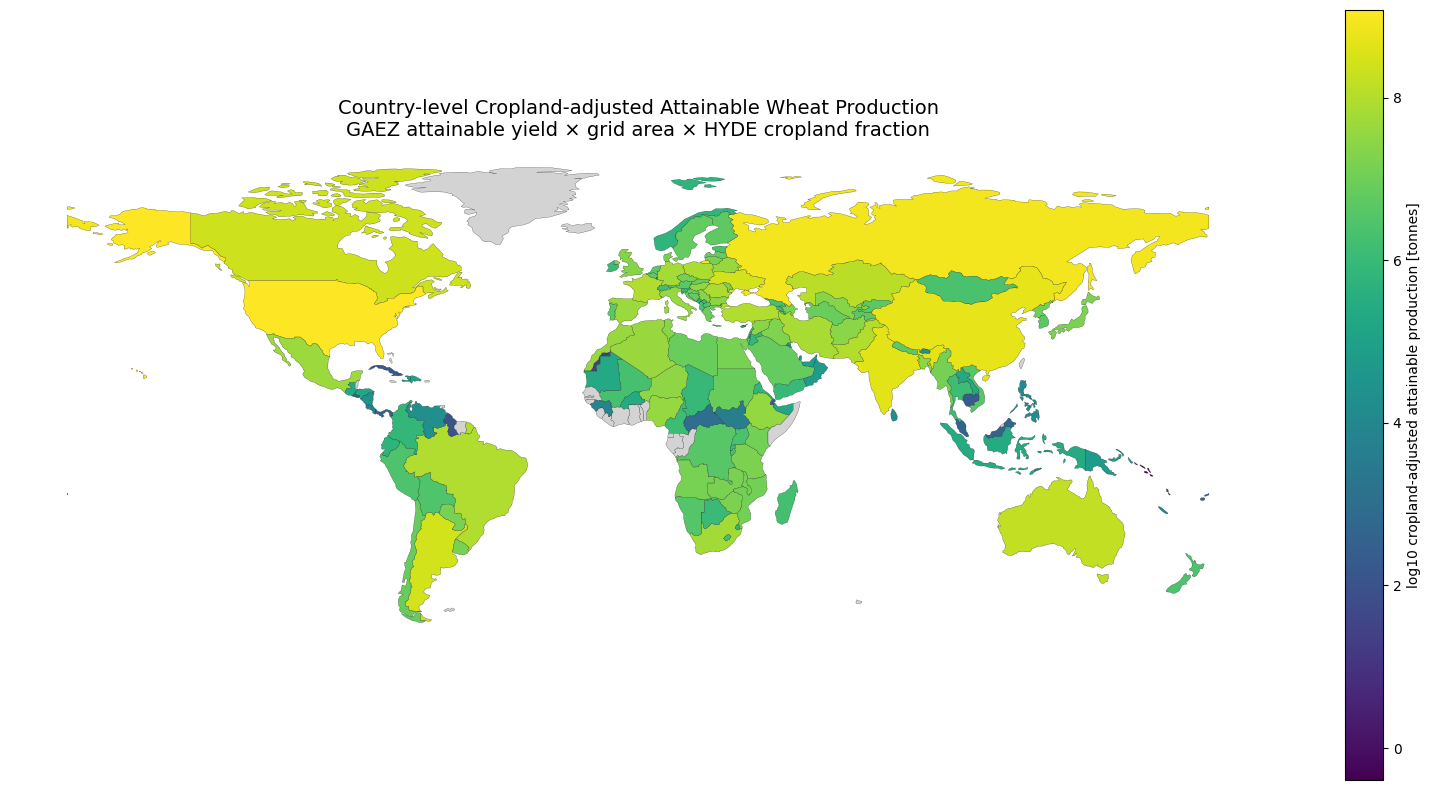

Saved map:
C:\masterresearch\Comparative_advantage\GAEZ\wheat\country_cropland_adjusted_attainable_production\wheat_cropland_adjusted_attainable_map_2024.png

FAOSTAT unit check


Unit
t    156
Name: count, dtype: int64


Number of compared countries:
116

Saved comparison CSV:
C:\masterresearch\Comparative_advantage\GAEZ\wheat\country_cropland_adjusted_attainable_production\wheat_cropland_adjusted_attainable_vs_actual_2024.csv


,country,iso_a3,region,cropland_adjusted_attainable_tonnes,actual_production_tonnes,actual_div_adjusted_attainable
2,China,CHN,Asia,5.501052e+08,1.401050e+08,0.254688
3,China,CHN,Asia,5.501052e+08,1.401000e+08,0.254679
4,India,IND,Asia,4.375941e+08,1.132924e+08,0.258898
1,Russia,RUS,Europe,8.276565e+08,8.258800e+07,0.099785
0,United States of America,USA,North America,1.196978e+09,5.365002e+07,0.044821
7,Canada,CAN,North America,2.194711e+08,3.593884e+07,0.163752
8,Australia,AUS,Oceania,1.674159e+08,3.411000e+07,0.203744
10,Pakistan,PAK,Asia,9.916377e+07,3.181444e+07,0.320827
12,France,-99,Europe,8.826373e+07,2.660694e+07,0.301448
5,Ukraine,UKR,Europe,2.786624e+08,2.244111e+07,0.080532



Correlation
Pearson log r     = 0.842, p = 2.754e-32
Spearman log rho = 0.847, p = 5.303e-33


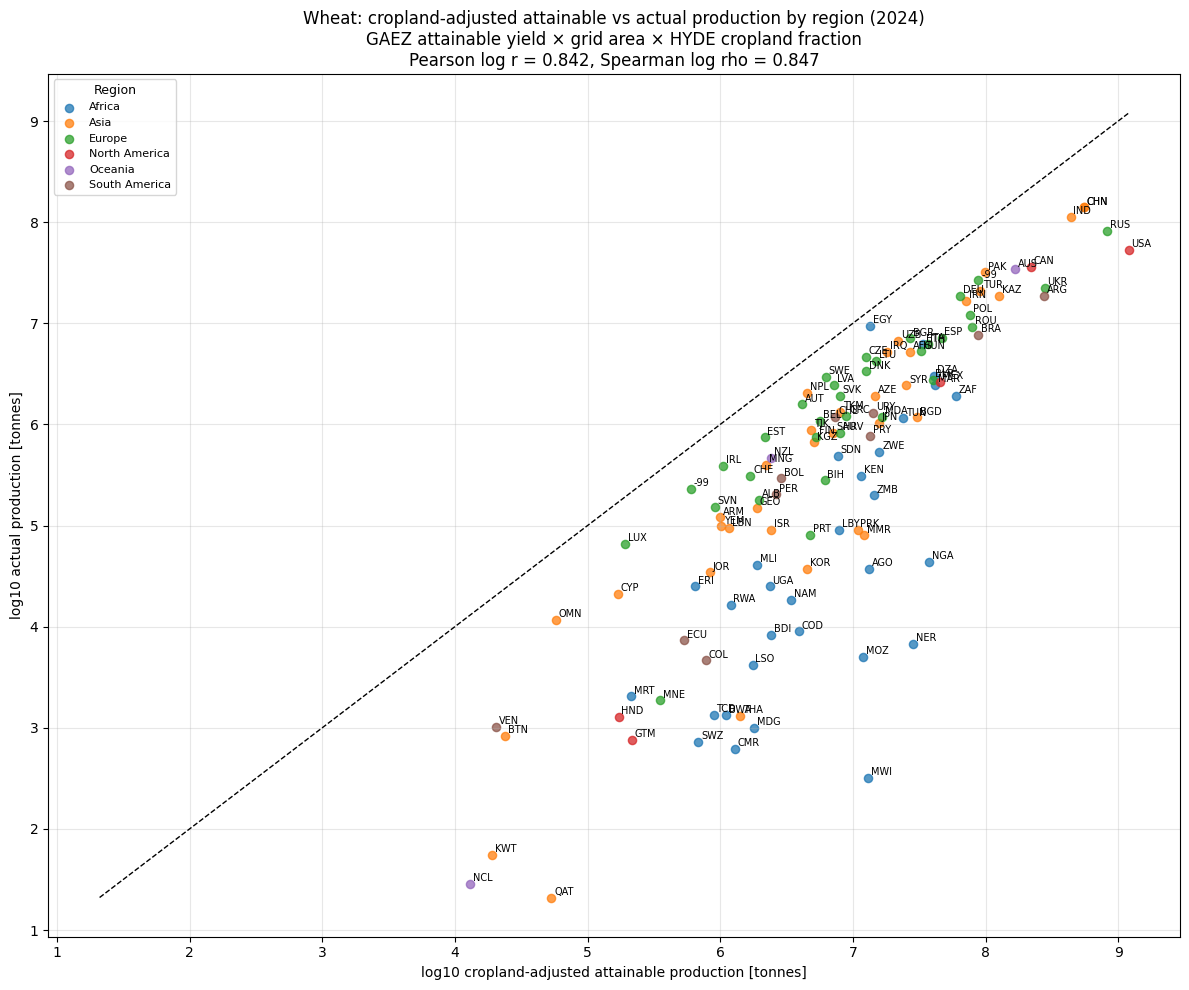

Saved scatter plot:
C:\masterresearch\Comparative_advantage\GAEZ\wheat\country_cropland_adjusted_attainable_production\wheat_cropland_adjusted_attainable_vs_actual_2024_scatter_by_region_labeled.png


In [7]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr
from rasterio.transform import from_bounds
from rasterio.features import rasterize


# ============================================================
# 0. 設定
# ============================================================

base_dir = r"C:\masterresearch\Comparative_advantage"

# GAEZ attainable yield：kg / ha
aty_path = (
    r"C:\masterresearch\Comparative_advantage\GAEZ\wheat"
    r"\AttainableYield_wheat.npy"
)

# 各グリッドの全面積：ha / grid
grid_area_path = (
    r"C:\masterresearch\Comparative_advantage\GAEZ"
    r"\grid_area_2160x4320_ha.npy"
)

# HYDE 3.4 cropland fraction：0～1
cropland_fraction_path = (
    r"C:\masterresearch\Comparative_advantage\HYDE3.4"
    r"\cropland_npys\yearly\cropland_fraction_2024.npy"
)

# FAOSTAT
faostat_csv = (
    r"C:\masterresearch\Comparative_advantage\wheat_production_2019"
    r"\Production_Crops_Livestock_E_All_Data_(Normalized).csv"
)

output_dir = (
    r"C:\masterresearch\Comparative_advantage\GAEZ\wheat"
    r"\country_cropland_adjusted_attainable_production"
)

os.makedirs(output_dir, exist_ok=True)

target_item_code = 15
target_year = 2024

out_country_csv = os.path.join(
    output_dir,
    f"wheat_cropland_adjusted_attainable_by_country_{target_year}.csv"
)

out_merged_csv = os.path.join(
    output_dir,
    f"wheat_cropland_adjusted_attainable_vs_actual_{target_year}.csv"
)

out_map = os.path.join(
    output_dir,
    f"wheat_cropland_adjusted_attainable_map_{target_year}.png"
)

out_scatter = os.path.join(
    output_dir,
    f"wheat_cropland_adjusted_attainable_vs_actual_"
    f"{target_year}_scatter_by_region_labeled.png"
)


# ============================================================
# 1. グリッドデータの読み込み
# ============================================================

wheat_ATY = np.load(
    aty_path,
    mmap_mode="r"
).astype(np.float32)

grid_area_ha = np.load(
    grid_area_path,
    mmap_mode="r"
).astype(np.float32)

cropland_fraction = np.load(
    cropland_fraction_path,
    mmap_mode="r"
).astype(np.float32)

print("Attainable yield shape :", wheat_ATY.shape)
print("Grid area shape        :", grid_area_ha.shape)
print("Cropland fraction shape:", cropland_fraction.shape)

if not (
    wheat_ATY.shape
    == grid_area_ha.shape
    == cropland_fraction.shape
):
    raise ValueError(
        "3つの配列のshapeが一致していません。\n"
        f"ATY       : {wheat_ATY.shape}\n"
        f"Grid area : {grid_area_ha.shape}\n"
        f"Cropland  : {cropland_fraction.shape}"
    )

height, width = wheat_ATY.shape


# ============================================================
# 2. cropland fractionの確認と処理
# ============================================================

cropland_fraction = np.asarray(
    cropland_fraction,
    dtype=np.float32
)

# infなどをNaNにする
cropland_fraction = np.where(
    np.isfinite(cropland_fraction),
    cropland_fraction,
    np.nan
)

print("\nCropland fraction before clipping")
print("Minimum:", np.nanmin(cropland_fraction))
print("Maximum:", np.nanmax(cropland_fraction))
print("Mean   :", np.nanmean(cropland_fraction))

# fractionなので0～1に制限
cropland_fraction = np.clip(
    cropland_fraction,
    0.0,
    1.0
)


# ============================================================
# 3. 緯度方向・経度方向の向きを確認
#
# GAEZとHYDEの両方が
# 行0 = 北緯90度側
# 行末 = 南緯90度側
# であれば、そのままでよい。
#
# 前に描いたfraction_2024で上下が正しかったなら
# FLIP_CROPLAND_LAT = Falseのままでよい。
# ============================================================

FLIP_CROPLAND_LAT = False

if FLIP_CROPLAND_LAT:
    cropland_fraction = np.flipud(cropland_fraction)
    print("Cropland fractionを上下反転しました。")
else:
    print("Cropland fractionは上下反転していません。")


# ============================================================
# 4. Cropland-adjusted attainable productionを計算
#
# kg/ha × ha/grid × cropland fraction
#     = kg/grid
#
# ここでは「各グリッドのcropland部分すべてで
# 小麦を生産した場合」という仮想的な生産可能量になる。
# ============================================================

valid = (
    np.isfinite(wheat_ATY)
    & np.isfinite(grid_area_ha)
    & np.isfinite(cropland_fraction)
    & (wheat_ATY > 0)
    & (grid_area_ha > 0)
    & (cropland_fraction > 0)
)

cropland_area_ha = np.where(
    valid,
    grid_area_ha * cropland_fraction,
    0.0
).astype(np.float32)

cropland_adjusted_prod_tonnes = np.where(
    valid,
    wheat_ATY * cropland_area_ha / 1000.0,
    0.0
).astype(np.float32)

print("\nGlobal values")
print(
    "Cropland area [ha]:",
    np.nansum(cropland_area_ha, dtype=np.float64)
)

print(
    "Cropland-adjusted attainable wheat production [tonnes]:",
    np.nansum(
        cropland_adjusted_prod_tonnes,
        dtype=np.float64
    )
)


# ============================================================
# 5. 国ポリゴンの読み込み
# ============================================================

world_url = (
    "https://naturalearth.s3.amazonaws.com/"
    "110m_cultural/ne_110m_admin_0_countries.zip"
)

world = gpd.read_file(
    world_url
).to_crs("EPSG:4326")

world = world[
    world["ADMIN"] != "Antarctica"
].copy()

world = world.reset_index(drop=True)

world["country_id"] = np.arange(
    1,
    len(world) + 1
)


# ============================================================
# 6. 国ポリゴンを2160 × 4320グリッドへrasterize
# ============================================================

transform = from_bounds(
    -180,
    -90,
    180,
    90,
    width,
    height
)

shapes = [
    (geometry, country_id)
    for geometry, country_id in zip(
        world.geometry,
        world["country_id"]
    )
    if geometry is not None
]

country_raster = rasterize(
    shapes=shapes,
    out_shape=(height, width),
    transform=transform,
    fill=0,
    dtype="int32"
)

print("\nCountry raster shape:", country_raster.shape)
print(
    "Number of country-assigned grids:",
    np.sum(country_raster > 0)
)


# ============================================================
# 7. 国別に合計
# ============================================================

rows = []

for _, country_row in world.iterrows():

    country_id = country_row["country_id"]

    country_mask = (
        country_raster == country_id
    )

    valid_country_mask = (
        country_mask & valid
    )

    adjusted_prod_tonnes = np.sum(
        cropland_adjusted_prod_tonnes[
            valid_country_mask
        ],
        dtype=np.float64
    )

    country_cropland_area_ha = np.sum(
        cropland_area_ha[
            valid_country_mask
        ],
        dtype=np.float64
    )

    # 国内のcropland部分について加重平均したattainable yield
    mean_attainable_yield_kg_ha = (
        adjusted_prod_tonnes
        * 1000.0
        / country_cropland_area_ha
        if country_cropland_area_ha > 0
        else np.nan
    )

    rows.append({
        "country_id": country_id,
        "country": country_row["ADMIN"],
        "iso_a3": country_row["ISO_A3"],
        "cropland_adjusted_attainable_tonnes":
            adjusted_prod_tonnes,
        "cropland_area_ha":
            country_cropland_area_ha,
        "mean_attainable_yield_on_cropland_kg_ha":
            mean_attainable_yield_kg_ha
    })


country_adjusted = pd.DataFrame(rows)

country_adjusted = country_adjusted.sort_values(
    "cropland_adjusted_attainable_tonnes",
    ascending=False
).reset_index(drop=True)

country_adjusted.to_csv(
    out_country_csv,
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved country CSV:")
print(out_country_csv)

display(
    country_adjusted.head(30)
)


# ============================================================
# 8. 国別cropland-adjusted attainable productionの地図
# ============================================================

world_map = world.merge(
    country_adjusted,
    on="country_id",
    how="left",
    suffixes=("", "_summary")
)

world_map["log10_cropland_adjusted_attainable"] = np.where(
    world_map[
        "cropland_adjusted_attainable_tonnes"
    ] > 0,
    np.log10(
        world_map[
            "cropland_adjusted_attainable_tonnes"
        ]
    ),
    np.nan
)

fig, ax = plt.subplots(
    figsize=(16, 8)
)

world_map.plot(
    column="log10_cropland_adjusted_attainable",
    ax=ax,
    legend=True,
    cmap="viridis",
    edgecolor="black",
    linewidth=0.15,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data / zero"
    },
    legend_kwds={
        "label":
            "log10 cropland-adjusted attainable production [tonnes]"
    }
)

ax.set_title(
    "Country-level Cropland-adjusted Attainable Wheat Production\n"
    "GAEZ attainable yield × grid area × HYDE cropland fraction",
    fontsize=14
)

ax.axis("off")

plt.tight_layout()

plt.savefig(
    out_map,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved map:")
print(out_map)


# ============================================================
# 9. FAOSTATの2024年小麦生産量を読み込む
# ============================================================

faostat = pd.read_csv(
    faostat_csv,
    low_memory=False
)

actual = faostat[
    (faostat["Item Code"] == target_item_code)
    & (faostat["Year"] == target_year)
    & (
        faostat["Element"].str.contains(
            "Production",
            case=False,
            na=False
        )
    )
].copy()

actual["actual_production_tonnes"] = pd.to_numeric(
    actual["Value"],
    errors="coerce"
)

actual = actual[
    [
        "Area",
        "Item",
        "Element",
        "Year",
        "Unit",
        "actual_production_tonnes"
    ]
].copy()

print("\nFAOSTAT unit check")
display(actual["Unit"].value_counts())


# ============================================================
# 10. FAOSTAT国名をNatural Earth国名に変換
# ============================================================

name_map = {
    "United States":
        "United States of America",

    "United States of America":
        "United States of America",

    "Russian Federation":
        "Russia",

    "China, mainland":
        "China",

    "Iran (Islamic Republic of)":
        "Iran",

    "Türkiye":
        "Turkey",

    "Viet Nam":
        "Vietnam",

    "Bolivia (Plurinational State of)":
        "Bolivia",

    "Venezuela (Bolivarian Republic of)":
        "Venezuela",

    "Syrian Arab Republic":
        "Syria",

    "Republic of Korea":
        "South Korea",

    "Democratic People's Republic of Korea":
        "North Korea",

    "Lao People's Democratic Republic":
        "Laos",

    "United Republic of Tanzania":
        "Tanzania",

    "Côte d'Ivoire":
        "Ivory Coast",

    "Congo":
        "Republic of the Congo",

    "Democratic Republic of the Congo":
        "Democratic Republic of the Congo",

    "Republic of Moldova":
        "Moldova",

    "North Macedonia":
        "Macedonia",

    "Czechia":
        "Czechia",

    "Eswatini":
        "eSwatini"
}

actual["country"] = actual["Area"].replace(
    name_map
)


# ============================================================
# 11. Cropland-adjusted attainableと実生産量を結合
# ============================================================

comparison = country_adjusted.merge(
    actual[
        [
            "country",
            "actual_production_tonnes"
        ]
    ],
    on="country",
    how="inner"
)

comparison = comparison[
    np.isfinite(
        comparison[
            "cropland_adjusted_attainable_tonnes"
        ]
    )
    & np.isfinite(
        comparison[
            "actual_production_tonnes"
        ]
    )
    & (
        comparison[
            "cropland_adjusted_attainable_tonnes"
        ] > 0
    )
    & (
        comparison[
            "actual_production_tonnes"
        ] > 0
    )
].copy()

comparison["log_adjusted_attainable"] = np.log10(
    comparison[
        "cropland_adjusted_attainable_tonnes"
    ]
)

comparison["log_actual"] = np.log10(
    comparison[
        "actual_production_tonnes"
    ]
)

comparison["actual_div_adjusted_attainable"] = (
    comparison["actual_production_tonnes"]
    / comparison[
        "cropland_adjusted_attainable_tonnes"
    ]
)


# ============================================================
# 12. 地域情報を付加
# ============================================================

region_info = world[
    [
        "ADMIN",
        "CONTINENT",
        "SUBREGION"
    ]
].copy()

comparison = comparison.merge(
    region_info,
    left_on="country",
    right_on="ADMIN",
    how="left"
)

comparison["region"] = comparison[
    "CONTINENT"
].fillna("Unknown")

# 必要ならロシアをEuropeとして固定
comparison.loc[
    comparison["iso_a3"] == "RUS",
    "region"
] = "Europe"

comparison.to_csv(
    out_merged_csv,
    index=False,
    encoding="utf-8-sig"
)

print("\nNumber of compared countries:")
print(len(comparison))

print("\nSaved comparison CSV:")
print(out_merged_csv)

display(
    comparison[
        [
            "country",
            "iso_a3",
            "region",
            "cropland_adjusted_attainable_tonnes",
            "actual_production_tonnes",
            "actual_div_adjusted_attainable"
        ]
    ].sort_values(
        "actual_production_tonnes",
        ascending=False
    ).head(30)
)


# ============================================================
# 13. 相関係数
# ============================================================

pearson_log, pearson_p = pearsonr(
    comparison["log_adjusted_attainable"],
    comparison["log_actual"]
)

spearman_log, spearman_p = spearmanr(
    comparison["log_adjusted_attainable"],
    comparison["log_actual"]
)

print("\nCorrelation")
print(
    f"Pearson log r     = {pearson_log:.3f}, "
    f"p = {pearson_p:.3e}"
)

print(
    f"Spearman log rho = {spearman_log:.3f}, "
    f"p = {spearman_p:.3e}"
)


# ============================================================
# 14. 地域別散布図
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 10)
)

regions = sorted(
    comparison["region"]
    .dropna()
    .unique()
)

for region in regions:

    sub = comparison[
        comparison["region"] == region
    ]

    ax.scatter(
        sub["log_adjusted_attainable"],
        sub["log_actual"],
        s=35,
        alpha=0.75,
        label=region
    )


# ============================================================
# 15. 45度線
# ============================================================

min_value = min(
    comparison[
        "log_adjusted_attainable"
    ].min(),
    comparison[
        "log_actual"
    ].min()
)

max_value = max(
    comparison[
        "log_adjusted_attainable"
    ].max(),
    comparison[
        "log_actual"
    ].max()
)

ax.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=1,
    color="black"
)


# ============================================================
# 16. ISO3ラベル
# ============================================================

for _, row in comparison.iterrows():

    ax.annotate(
        row["iso_a3"],
        (
            row["log_adjusted_attainable"],
            row["log_actual"]
        ),
        xytext=(2, 2),
        textcoords="offset points",
        fontsize=7
    )


# ============================================================
# 17. 図の設定
# ============================================================

ax.set_xlabel(
    "log10 cropland-adjusted attainable production [tonnes]"
)

ax.set_ylabel(
    "log10 actual production [tonnes]"
)

ax.set_title(
    "Wheat: cropland-adjusted attainable vs actual "
    f"production by region ({target_year})\n"
    "GAEZ attainable yield × grid area × "
    "HYDE cropland fraction\n"
    f"Pearson log r = {pearson_log:.3f}, "
    f"Spearman log rho = {spearman_log:.3f}"
)

ax.grid(
    alpha=0.3
)

ax.legend(
    title="Region",
    loc="best",
    fontsize=8,
    title_fontsize=9
)

plt.tight_layout()

plt.savefig(
    out_scatter,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved scatter plot:")
print(out_scatter)

ATY shape              : (2160, 4320)
Grid area shape        : (2160, 4320)
Cropland fraction shape: (2160, 4320)

Cropland fraction statistics
minimum: 0.0
maximum: 1.0
mean   : 0.1025461

Latitude direction:
No vertical flip is applied.

Valid cells: 719609

Global totals
Total cropland area [ha]: 1,190,566,106
Cropland-adjusted attainable production [tonnes]: 5,859,493,261

Number of Natural Earth countries: 176
Country raster shape: (2160, 4320)
Country-assigned cells: 2227348

Saved country-level result:
C:\masterresearch\Comparative_advantage\GAEZ\wheat\country_cropland_adjusted_attainable_production\wheat_cropland_adjusted_attainable_production_by_country.csv


,country_id,country,iso_a3,continent,subregion,cropland_area_ha,cropland_adjusted_attainable_tonnes,mean_attainable_yield_on_cropland_kg_ha
0,5,United States of America,USA,North America,Northern America,1.600699e+08,1.196978e+09,7477.842410
1,19,Russia,RUS,Europe,Eastern Europe,1.230795e+08,8.276565e+08,6724.569346
2,140,China,CHN,Asia,Eastern Asia,1.312426e+08,5.501052e+08,4191.513625
3,99,India,IND,Asia,Southern Asia,1.272317e+08,4.375941e+08,3439.347236
4,113,Ukraine,UKR,Europe,Eastern Europe,3.226206e+07,2.786624e+08,8637.463983
5,10,Argentina,ARG,South America,South America,4.456885e+07,2.778825e+08,6234.903019
6,4,Canada,CAN,North America,Northern America,3.774707e+07,2.194711e+08,5814.254053
7,138,Australia,AUS,Oceania,Australia and New Zealand,3.121390e+07,1.674159e+08,5363.505190
8,6,Kazakhstan,KAZ,Asia,Central Asia,2.974783e+07,1.257415e+08,4226.914625
9,103,Pakistan,PAK,Asia,Southern Asia,3.105908e+07,9.916377e+07,3192.746007



FAOSTAT unit check


Unit
t    156
Name: count, dtype: int64


Matched countries: 117


,country,iso_a3,cropland_adjusted_attainable_tonnes,actual_production_tonnes,log_adjusted_attainable,log_actual
2,China,CHN,5.501052e+08,2.802050e+08,8.740446,8.447476
3,India,IND,4.375941e+08,1.132924e+08,8.641071,8.054201
1,Russia,RUS,8.276565e+08,8.258800e+07,8.917850,7.916917
0,United States of America,USA,1.196978e+09,5.365002e+07,9.078086,7.729570
6,Canada,CAN,2.194711e+08,3.593884e+07,8.341377,7.555564
7,Australia,AUS,1.674159e+08,3.411000e+07,8.223797,7.532882
9,Pakistan,PAK,9.916377e+07,3.181444e+07,7.996353,7.502624
11,France,-99,8.826373e+07,2.660694e+07,7.945782,7.424995
4,Ukraine,UKR,2.786624e+08,2.244111e+07,8.445078,7.351044
10,Turkey,TUR,9.154627e+07,2.080000e+07,7.961641,7.318063



Region counts


region
Europe           36
Asia             34
Africa           29
South America    10
North America     5
Oceania           3
Name: count, dtype: int64


Saved merged result:
C:\masterresearch\Comparative_advantage\GAEZ\wheat\country_cropland_adjusted_attainable_production\wheat_cropland_adjusted_attainable_vs_actual_2024.csv

========== Correlation ==========
Pearson raw    : r = 0.642, p = 5.99e-15
Spearman raw   : rho = 0.840, p = 2.19e-32
Pearson log10  : r = 0.836, p = 8.71e-32
Spearman log10 : rho = 0.840, p = 2.19e-32


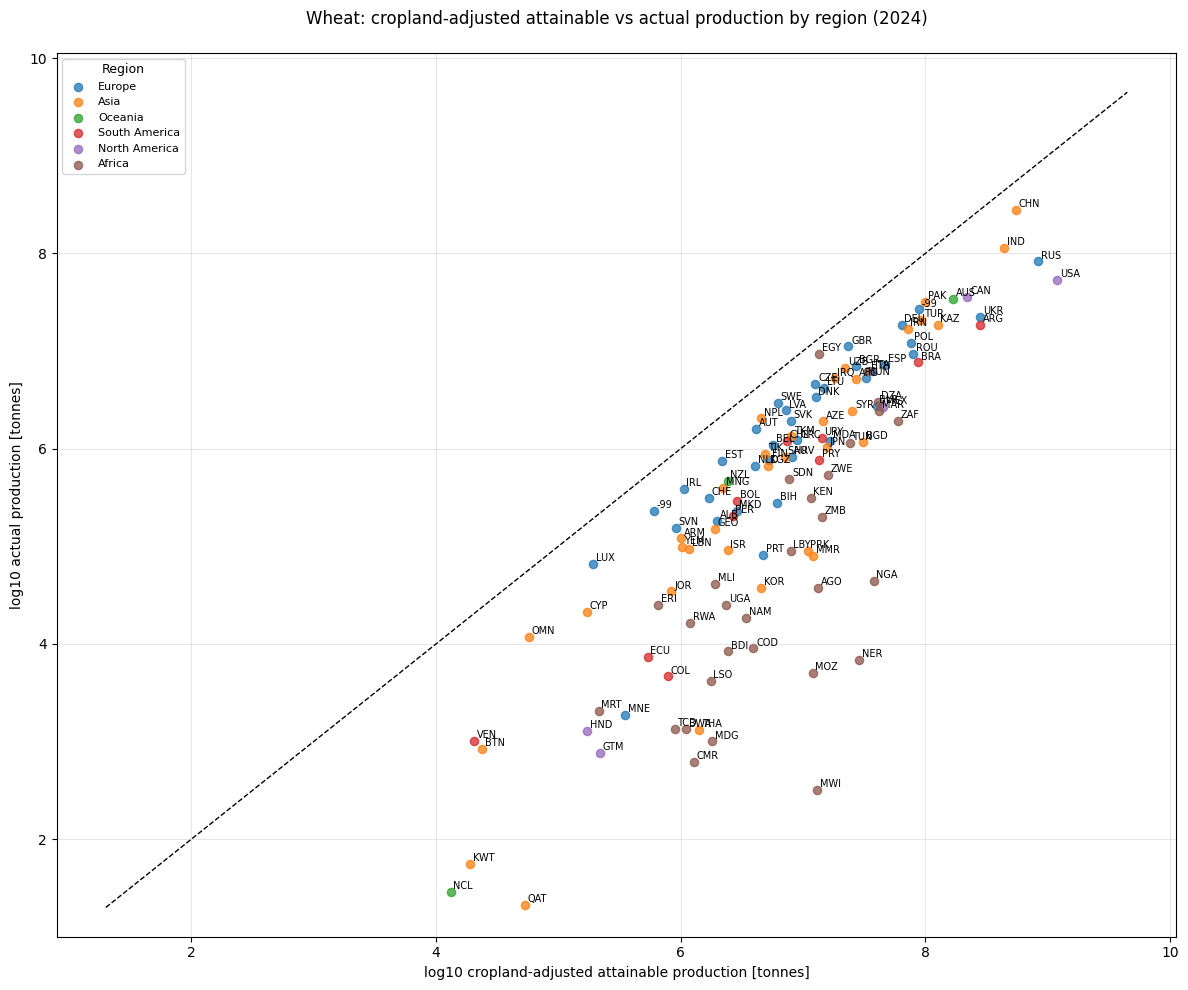

C:\masterresearch\Comparative_advantage\GAEZ\wheat\country_cropland_adjusted_attainable_production\wheat_cropland_adjusted_attainable_vs_actual_2024_scatter_by_region_labeled.png


In [12]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr
from rasterio.transform import from_bounds
from rasterio.features import rasterize


# ============================================================
# 0. 設定
# ============================================================

target_item_code = 15
target_year = 2024


# GAEZ attainable yield
# 単位：kg / ha
aty_path = (
    r"C:\masterresearch\Comparative_advantage\GAEZ\wheat"
    r"\AttainableYield_wheat.npy"
)


# GAEZグリッド面積
# 単位：ha / grid
area_path = (
    r"C:\masterresearch\Comparative_advantage\GAEZ"
    r"\grid_area_2160x4320_ha.npy"
)


# HYDE 3.4 cropland fraction
# 単位：0～1
cropland_fraction_path = (
    r"C:\masterresearch\Comparative_advantage\HYDE3.4"
    r"\cropland_npys\yearly\cropland_fraction_2024.npy"
)


# FAOSTAT
faostat_csv = (
    r"C:\masterresearch\Comparative_advantage\wheat_production_2019"
    r"\Production_Crops_Livestock_E_All_Data_(Normalized).csv"
)


# 保存先
output_dir = (
    r"C:\masterresearch\Comparative_advantage\GAEZ\wheat"
    r"\country_cropland_adjusted_attainable_production"
)

os.makedirs(
    output_dir,
    exist_ok=True
)


out_country_csv = os.path.join(
    output_dir,
    "wheat_cropland_adjusted_attainable_production_by_country.csv"
)


out_merged_csv = os.path.join(
    output_dir,
    f"wheat_cropland_adjusted_attainable_vs_actual_{target_year}.csv"
)


out_scatter = os.path.join(
    output_dir,
    f"wheat_cropland_adjusted_attainable_vs_actual_"
    f"{target_year}_scatter_by_region_labeled.png"
)


# ============================================================
# 1. グリッドデータを読み込む
# ============================================================

wheat_ATY = np.load(
    aty_path
).astype(np.float32)


grid_area_ha = np.load(
    area_path
).astype(np.float32)


fraction_2024 = np.load(
    cropland_fraction_path
).astype(np.float32)


print("ATY shape              :", wheat_ATY.shape)
print("Grid area shape        :", grid_area_ha.shape)
print("Cropland fraction shape:", fraction_2024.shape)


if not (
    wheat_ATY.shape
    == grid_area_ha.shape
    == fraction_2024.shape
):

    raise ValueError(
        "配列のshapeが一致していません。\n"
        f"ATY              : {wheat_ATY.shape}\n"
        f"Grid area        : {grid_area_ha.shape}\n"
        f"Cropland fraction: {fraction_2024.shape}"
    )


height, width = wheat_ATY.shape


# ============================================================
# 2. データを整理
# ============================================================

# infをNaNにする
wheat_ATY[~np.isfinite(wheat_ATY)] = np.nan
grid_area_ha[~np.isfinite(grid_area_ha)] = np.nan
fraction_2024[~np.isfinite(fraction_2024)] = np.nan


# cropland fractionは0～1に制限
fraction_2024 = np.clip(
    fraction_2024,
    0.0,
    1.0
)


print("\nCropland fraction statistics")
print("minimum:", np.nanmin(fraction_2024))
print("maximum:", np.nanmax(fraction_2024))
print("mean   :", np.nanmean(fraction_2024))


# ============================================================
# 3. グリッドの上下方向について
#
# GAEZもHYDEも配列の先頭行が北側なので、
# flipudは行わない
# ============================================================

print("\nLatitude direction:")
print("No vertical flip is applied.")


# ============================================================
# 4. 有効セル
# ============================================================

valid = (
    np.isfinite(wheat_ATY)
    & np.isfinite(grid_area_ha)
    & np.isfinite(fraction_2024)
    & (wheat_ATY > 0)
    & (grid_area_ha > 0)
    & (fraction_2024 > 0)
)


print(
    "\nValid cells:",
    np.sum(valid)
)


# ============================================================
# 5. グリッドごとのcropland面積
#
# ha/grid × fraction
# = cropland ha/grid
# ============================================================

cropland_area_ha = np.zeros(
    wheat_ATY.shape,
    dtype=np.float32
)


cropland_area_ha[valid] = (
    grid_area_ha[valid]
    * fraction_2024[valid]
)


# ============================================================
# 6. Cropland-adjusted attainable production
#
# kg/ha × cropland ha/grid
# = kg/grid
#
# kg ÷ 1000
# = tonnes/grid
# ============================================================

cropland_adjusted_prod_tonnes = np.zeros(
    wheat_ATY.shape,
    dtype=np.float32
)


cropland_adjusted_prod_tonnes[valid] = (
    wheat_ATY[valid]
    * cropland_area_ha[valid]
    / 1000.0
)


print("\nGlobal totals")

print(
    "Total cropland area [ha]:",
    f"{np.sum(cropland_area_ha, dtype=np.float64):,.0f}"
)

print(
    "Cropland-adjusted attainable production [tonnes]:",
    f"{np.sum(cropland_adjusted_prod_tonnes, dtype=np.float64):,.0f}"
)


# ============================================================
# 7. Natural Earthの国境データを読み込む
# ============================================================

world_url = (
    "https://naturalearth.s3.amazonaws.com/"
    "110m_cultural/ne_110m_admin_0_countries.zip"
)


world = gpd.read_file(
    world_url
).to_crs(
    "EPSG:4326"
)


world = world[
    world["ADMIN"] != "Antarctica"
].copy()


world = world.reset_index(
    drop=True
)


world["country_id"] = np.arange(
    1,
    len(world) + 1,
    dtype=np.int32
)


print(
    "\nNumber of Natural Earth countries:",
    len(world)
)


# ============================================================
# 8. 国境を2160 × 4320グリッドにrasterize
# ============================================================

transform = from_bounds(
    -180,
    -90,
    180,
    90,
    width,
    height
)


shapes = [
    (
        geometry,
        int(country_id)
    )
    for geometry, country_id
    in zip(
        world.geometry,
        world["country_id"]
    )
    if geometry is not None
]


country_raster = rasterize(
    shapes=shapes,
    out_shape=(
        height,
        width
    ),
    transform=transform,
    fill=0,
    dtype="int32"
)


print(
    "Country raster shape:",
    country_raster.shape
)

print(
    "Country-assigned cells:",
    np.sum(country_raster > 0)
)


# ============================================================
# 9. 国別に集計
# ============================================================

rows = []


for _, row in world.iterrows():

    country_id = int(
        row["country_id"]
    )

    country_mask = (
        country_raster == country_id
    )

    country_valid = (
        country_mask
        & valid
    )


    country_cropland_area_ha = np.sum(
        cropland_area_ha[country_valid],
        dtype=np.float64
    )


    country_adjusted_prod_tonnes = np.sum(
        cropland_adjusted_prod_tonnes[
            country_valid
        ],
        dtype=np.float64
    )


    if country_cropland_area_ha > 0:

        mean_attainable_yield_kg_ha = (
            country_adjusted_prod_tonnes
            * 1000.0
            / country_cropland_area_ha
        )

    else:

        mean_attainable_yield_kg_ha = np.nan


    rows.append(
        {
            "country_id":
                country_id,

            "country":
                row["ADMIN"],

            "iso_a3":
                row["ISO_A3"],

            "continent":
                row["CONTINENT"],

            "subregion":
                row["SUBREGION"],

            "cropland_area_ha":
                country_cropland_area_ha,

            "cropland_adjusted_attainable_tonnes":
                country_adjusted_prod_tonnes,

            "mean_attainable_yield_on_cropland_kg_ha":
                mean_attainable_yield_kg_ha
        }
    )


country_adjusted = pd.DataFrame(
    rows
)


country_adjusted = country_adjusted.sort_values(
    "cropland_adjusted_attainable_tonnes",
    ascending=False
).reset_index(
    drop=True
)


country_adjusted.to_csv(
    out_country_csv,
    index=False,
    encoding="utf-8-sig"
)


print("\nSaved country-level result:")
print(out_country_csv)


display(
    country_adjusted.head(30)
)


# ============================================================
# 10. FAOSTATを読み込む
# ============================================================

df = pd.read_csv(
    faostat_csv,
    low_memory=False
)


# ============================================================
# 11. 2024年の小麦実生産量を抽出
# ============================================================

wheat_actual = df[
    (df["Item Code"] == target_item_code)
    & (df["Year"] == target_year)
    & (
        df["Element"]
        .str.contains(
            "Production",
            case=False,
            na=False
        )
    )
].copy()


wheat_actual["actual_production_tonnes"] = pd.to_numeric(
    wheat_actual["Value"],
    errors="coerce"
)


print("\nFAOSTAT unit check")

display(
    wheat_actual["Unit"].value_counts(
        dropna=False
    )
)


wheat_actual = wheat_actual[
    [
        "Area",
        "actual_production_tonnes"
    ]
].copy()


# ============================================================
# 12. FAOSTAT国名をNatural Earth国名に合わせる
#
# 既存ノートブックで使っていた対応表
# ============================================================

name_map = {
    "United States":
        "United States of America",

    "United States of America":
        "United States of America",

    "Russian Federation":
        "Russia",

    "China, mainland":
        "China",

    "Iran (Islamic Republic of)":
        "Iran",

    "Türkiye":
        "Turkey",

    "Viet Nam":
        "Vietnam",

    "Bolivia (Plurinational State of)":
        "Bolivia",

    "Venezuela (Bolivarian Republic of)":
        "Venezuela",

    "Syrian Arab Republic":
        "Syria",

    "Republic of Korea":
        "South Korea",

    "Democratic People's Republic of Korea":
        "North Korea",

    "Lao People's Democratic Republic":
        "Laos",

    "United Republic of Tanzania":
        "Tanzania",

    "Czechia":
        "Czechia",

    "Republic of Moldova":
        "Moldova",

    "Netherlands (Kingdom of the)":
        "Netherlands",

    "United Kingdom of Great Britain and Northern Ireland":
        "United Kingdom",

    "Serbia":
        "Serbia",

    "Sudan (former)":
        "Sudan"
}


wheat_actual["country"] = wheat_actual[
    "Area"
].replace(
    name_map
)


# ============================================================
# 13. 同じ国が複数行ある場合に国別合計
# ============================================================

actual_country = (
    wheat_actual
    .groupby(
        "country",
        as_index=False
    )
    .agg(
        actual_production_tonnes=(
            "actual_production_tonnes",
            "sum"
        )
    )
)


# ============================================================
# 14. Cropland-adjusted attainableとactualを結合
# ============================================================

df_corr = country_adjusted.merge(
    actual_country,
    on="country",
    how="inner"
)


df_corr = df_corr[
    np.isfinite(
        df_corr[
            "cropland_adjusted_attainable_tonnes"
        ]
    )
    & np.isfinite(
        df_corr[
            "actual_production_tonnes"
        ]
    )
    & (
        df_corr[
            "cropland_adjusted_attainable_tonnes"
        ] > 0
    )
    & (
        df_corr[
            "actual_production_tonnes"
        ] > 0
    )
].copy()


# ============================================================
# 15. 対数変換
# ============================================================

df_corr[
    "log_adjusted_attainable"
] = np.log10(
    df_corr[
        "cropland_adjusted_attainable_tonnes"
    ]
)


df_corr[
    "log_actual"
] = np.log10(
    df_corr[
        "actual_production_tonnes"
    ]
)


df_corr[
    "actual_div_adjusted_attainable"
] = (
    df_corr[
        "actual_production_tonnes"
    ]
    /
    df_corr[
        "cropland_adjusted_attainable_tonnes"
    ]
)


print(
    "\nMatched countries:",
    len(df_corr)
)


display(
    df_corr[
        [
            "country",
            "iso_a3",
            "cropland_adjusted_attainable_tonnes",
            "actual_production_tonnes",
            "log_adjusted_attainable",
            "log_actual"
        ]
    ]
    .sort_values(
        "actual_production_tonnes",
        ascending=False
    )
    .head(30)
)


# ============================================================
# 16. 地域区分
# ============================================================

df_corr["region"] = df_corr[
    "continent"
].fillna(
    "Unknown"
)


# 前の図と同様、ロシアはEurope扱い
df_corr.loc[
    df_corr["iso_a3"] == "RUS",
    "region"
] = "Europe"


print("\nRegion counts")

display(
    df_corr["region"].value_counts()
)


# ============================================================
# 17. CSV保存
# ============================================================

df_corr.to_csv(
    out_merged_csv,
    index=False,
    encoding="utf-8-sig"
)


print("\nSaved merged result:")
print(out_merged_csv)


# ============================================================
# 18. 相関係数
# ============================================================

pearson_raw, pearson_raw_p = pearsonr(
    df_corr[
        "cropland_adjusted_attainable_tonnes"
    ],
    df_corr[
        "actual_production_tonnes"
    ]
)


spearman_raw, spearman_raw_p = spearmanr(
    df_corr[
        "cropland_adjusted_attainable_tonnes"
    ],
    df_corr[
        "actual_production_tonnes"
    ]
)


pearson_log, pearson_log_p = pearsonr(
    df_corr[
        "log_adjusted_attainable"
    ],
    df_corr[
        "log_actual"
    ]
)


spearman_log, spearman_log_p = spearmanr(
    df_corr[
        "log_adjusted_attainable"
    ],
    df_corr[
        "log_actual"
    ]
)


print("\n========== Correlation ==========")

print(
    f"Pearson raw    : "
    f"r = {pearson_raw:.3f}, "
    f"p = {pearson_raw_p:.3g}"
)

print(
    f"Spearman raw   : "
    f"rho = {spearman_raw:.3f}, "
    f"p = {spearman_raw_p:.3g}"
)

print(
    f"Pearson log10  : "
    f"r = {pearson_log:.3f}, "
    f"p = {pearson_log_p:.3g}"
)

print(
    f"Spearman log10 : "
    f"rho = {spearman_log:.3f}, "
    f"p = {spearman_log_p:.3g}"
)


# ============================================================
# 19. 前の図と同じ地域色
# ============================================================
# ============================================================
# 散布図
# ============================================================

region_colors = {
    "Europe": "tab:blue",
    "Asia": "tab:orange",
    "Oceania": "tab:green",
    "South America": "tab:red",
    "North America": "tab:purple",
    "Africa": "tab:brown",
}

region_order = [
    "Europe",
    "Asia",
    "Oceania",
    "South America",
    "North America",
    "Africa",
]


fig, ax = plt.subplots(
    figsize=(12, 10)
)


for region in region_order:

    sub = df_corr[
        df_corr["region"] == region
    ]

    if sub.empty:
        continue

    ax.scatter(
        sub["log_adjusted_attainable"],
        sub["log_actual"],
        s=35,
        alpha=0.75,
        color=region_colors[region],
        label=region,
    )


# 45度線
ax.plot(
    [1.3, 9.65],
    [1.3, 9.65],
    linestyle="--",
    linewidth=1,
    color="black",
)


# ISO3ラベル
for _, row in df_corr.iterrows():

    ax.annotate(
        row["iso_a3"],
        (
            row["log_adjusted_attainable"],
            row["log_actual"],
        ),
        xytext=(2, 2),
        textcoords="offset points",
        fontsize=7,
    )


# ============================================================
# 元の attainable vs actual production 図と同じ軸
# ============================================================

ax.set_xlim(
    0.9,
    10.05,
)

ax.set_ylim(
    1.0,
    10.05,
)

ax.set_xticks(
    [2, 4, 6, 8, 10]
)

ax.set_yticks(
    [2, 4, 6, 8, 10]
)


ax.set_xlabel(
    "log10 cropland-adjusted attainable production [tonnes]"
)

ax.set_ylabel(
    "log10 actual production [tonnes]"
)

ax.set_title(
    "Wheat: cropland-adjusted attainable vs actual "
    f"production by region ({target_year})\n"
)

ax.grid(
    alpha=0.3
)

ax.legend(
    title="Region",
    loc="upper left",
    fontsize=8,
    title_fontsize=9,
)

plt.tight_layout()

plt.savefig(
    out_scatter,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(out_scatter)
